# FT-Transformer on Home Credit

This notebook trains and evaluates an **FT-Transformer** (Feature Tokenizer
Transformer) on the Home Credit Default Risk dataset, with the full
experimental suite needed for the study's deep-learning-vs-baselines
comparison.

It mirrors `03_home_credit_ft_transformer.ipynb` exactly — same architecture,
same experiments, same shared `src/` code — applied to the second dataset. The
only differences are the data loader, the target column (`TARGET`), and the
dataset-specific feature names used in the decision-boundary analysis (§19).

The notebook is organized in two parts:

* **Part 1 — Sanity run (Sections 1-8).** Trains a single FT-Transformer with
  the original FT-Transformer paper's recommended default hyperparameters to
  confirm the architecture trains end-to-end. Produces one baseline row in the
  results table.
* **Part 2 — Full experiments (Sections 9-19).** Imbalance-handling study,
  categorical-tokenizer ablation, 30-trial Optuna tuning, sensitivity sweeps,
  sample-size study, MLP baseline, attention-map extraction, and a
  decision-boundary analysis.

Both parts live in **this single notebook** and run top-to-bottom. Preprocessing
is identical to the baseline notebook (`02_home_credit_baselines.ipynb`) — the
shared `src/` module guarantees the same train/valid/test split and the same
features, so model comparisons are fair.

## Architecture (Part 1 sanity-run defaults)

| Component | Value |
| :--- | :--- |
| Library | `rtdl_revisiting_models` |
| `n_blocks` | 3 |
| `d_token` (a.k.a. `d_block`) | 192 |
| `attention_n_heads` | 8 |
| `attention_dropout` | 0.2 |
| `ffn_d_hidden_multiplier` | 4/3 |
| `ffn_dropout` | 0.1 |
| `residual_dropout` | 0.0 |
| Optimizer | AdamW |
| Learning rate | 1e-4 |
| Weight decay | 1e-5 |
| Batch size | 512 |
| Max epochs | 50 |
| Early stopping patience | 10 (on validation AUC) |
| Mixed precision | Yes (FP16 with autocast) |

Part 2's Optuna search tunes these (including `attention_n_heads`, constrained
to divisors of `d_token`).

## Tracking

Every model run persists via the shared `tracking` module: per-model metrics,
tuned hyperparameters, Optuna study history, test-set predictions, training
timings, and an environment snapshot. Test-set summaries accumulate in
`results/summary_test_metrics_home_credit.csv`.

## 1. Setup

In [1]:
# Install dependencies (uncomment on a fresh environment)
!pip install -q torch rtdl_revisiting_models optuna tqdm
!pip install -q scikit-learn pandas numpy joblib

In [2]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import torch

# Make the shared src/ module importable when this notebook lives under notebooks/
sys.path.insert(0, os.path.abspath(".."))

from src.datasets import preprocess_home_credit
from src.preprocessing import preprocess_data_pipeline, seed_everything
from src.evaluation import report_performance
from src.tracking import (
    ExperimentLogger,
    time_block,
    capture_environment,
    save_run_artifacts,
    measure_inference_time,
    load_summary,
    load_timings,
)
from src.ft_transformer_utils import (
    make_dataloaders,
    build_ft_transformer,
    train_ft_transformer,
    FTTransformerWrapper,
    set_torch_seed,
    count_parameters,
    get_device,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.options.display.max_rows = 200
pd.options.display.max_columns = 200

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)   # python + numpy
set_torch_seed(RANDOM_SEED)    # torch + cuda

DEVICE = get_device()
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


### 1.1 DEV_MODE flag

Set `DEV_MODE = True` for a fast end-to-end verification (subsample rows + cap
epochs). Flip to `False` once you've confirmed everything runs.

In [3]:
DEV_MODE = True   # set False for the real run

if DEV_MODE:
    DEV_N_ROWS    = 10_000   # subsample of train+valid+test combined
    DEV_MAX_EPOCHS = 3
    print("⚠️  DEV_MODE is ON — subsampled data, capped epochs")
else:
    DEV_N_ROWS    = None
    DEV_MAX_EPOCHS = 50
    print("DEV_MODE is OFF — full data, full epochs")

⚠️  DEV_MODE is ON — subsampled data, capped epochs


### 1.2 Paths and tracking

In [4]:
# --- Optional: Google Colab Drive mount ---
# Uncomment the three lines below if you're running on Colab and want to read
# data from / write artifacts to your Drive. Skip on local, server, or Kaggle
# runs. The next cell auto-routes through DRIVE_ROOT when defined.

from google.colab import drive
drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/credit_risk_modeling"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# When running locally, repo root is one directory up (notebook is in notebooks/).
# When running on Colab with the cell above uncommented, DRIVE_ROOT takes precedence.
_BASE = globals().get("DRIVE_ROOT", "..")
DATA_PATH      = f"{_BASE}/data/home_credit_default.csv"
ARTIFACTS_DIR  = f"{_BASE}/artifacts/home_credit"
RESULTS_DIR    = f"{_BASE}/results"

logger = ExperimentLogger(
    dataset="home_credit",
    artifacts_dir=ARTIFACTS_DIR,
    results_dir=RESULTS_DIR,
)
print(f"DATA_PATH      = {DATA_PATH}")
print(f"ARTIFACTS_DIR  = {ARTIFACTS_DIR}")
print(f"RESULTS_DIR    = {RESULTS_DIR}")

# Capture environment once per session — overwrites environment.json with
# the FT-Transformer session's GPU + library versions.
capture_environment(logger, seed=RANDOM_SEED);

DATA_PATH      = /content/drive/MyDrive/credit_risk_modeling/data/home_credit_default.csv
ARTIFACTS_DIR  = /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit
RESULTS_DIR    = /content/drive/MyDrive/credit_risk_modeling/results
  [env] captured -> /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/environment.json


## 2. Data Loading and Cleaning

In [6]:
df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")

# SK_ID_CURR is a join key from upstream aggregation; not a feature
if "SK_ID_CURR" in df.columns:
    df = df.drop(columns=["SK_ID_CURR"])

df = preprocess_home_credit(df)
print(f"After domain cleaning: {df.shape}")

# DEV_MODE: stratified subsample of the cleaned data, BEFORE splitting
if DEV_MODE and DEV_N_ROWS and len(df) > DEV_N_ROWS:
    from sklearn.model_selection import train_test_split
    df, _ = train_test_split(
        df, train_size=DEV_N_ROWS, stratify=df["TARGET"], random_state=RANDOM_SEED
    )
    df = df.reset_index(drop=True)
    print(f"DEV_MODE subsample: {df.shape}")

Raw shape: (307511, 381)
After domain cleaning: (307507, 380)
DEV_MODE subsample: (10000, 380)


## 3. Preprocessing

Same pipeline as the baseline notebook — `preprocess_data_pipeline` returns
the `PreprocessedData` object with **separate numeric and categorical
arrays**. FT-Transformer consumes those separately along with
`cat_cardinalities` (which the model uses to size its categorical embeddings).

In [7]:
data = preprocess_data_pipeline(
    df, target="TARGET", corr_threshold=0.9, missing_threshold=0.9
)

print("\nDataset Split Summary")
print("-" * 40)
print(f"Train (numeric/cat) : {data.x_num_train.shape} / {data.x_cat_train.shape}")
print(f"Valid (numeric/cat) : {data.x_num_valid.shape} / {data.x_cat_valid.shape}")
print(f"Test  (numeric/cat) : {data.x_num_test.shape} / {data.x_cat_test.shape}")
print()
print(f"Numeric features      : {len(data.num_cols)}")
print(f"Categorical features  : {len(data.cat_cols)}")
print(f"Cat cardinalities     : {data.cat_cardinalities}")
print(f"Target rate (train)   : {data.y_train.mean():.4f}")

Step 1: Stratified split (64/16/20)
  Train=6,400 | Valid=1,600 | Test=2,000
Step 2: Missing-value column filter
  Threshold: 90% | Dropped 7 columns
Step 3: Correlation drop (numeric)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Numeric features before: 358 | Dropped: 67
Step 4: Median imputation (numeric)
Step 5: Label encoding (categorical)
Step 6: Standard scaling (numeric)

Final feature counts: numeric=291 | categorical=14 | total=305
Categorical cardinalities: [2, 2, 8, 4, 5, 5, 6, 19, 7, 58, 5, 4, 8, 3]

Dataset Split Summary
----------------------------------------
Train (numeric/cat) : (6400, 291) / (6400, 14)
Valid (numeric/cat) : (1600, 291) / (1600, 14)
Test  (numeric/cat) : (2000, 291) / (2000, 14)

Numeric features      : 291
Categorical features  : 14
Cat cardinalities     : [2, 2, 8, 4, 5, 5, 6, 19, 7, 58, 5, 4, 8, 3]
Target rate (train)   : 0.0808


## 4. PyTorch DataLoaders

`make_dataloaders` wraps the three splits as `TabularDataset` objects (float32
for numerics, long for categoricals) and constructs DataLoaders.

In [8]:
BATCH_SIZE = 256

train_loader, valid_loader, test_loader = make_dataloaders(
    data,
    batch_size=BATCH_SIZE,
    num_workers=0,   # 0 is safest on Colab
)
print(f"Batches per epoch: train={len(train_loader)}, "
      f"valid={len(valid_loader)}, test={len(test_loader)}")

Batches per epoch: train=25, valid=4, test=4


## 5. Build the FT-Transformer

`build_ft_transformer` constructs the model using the original FT-Transformer
paper's recommended
defaults. The constructor takes `n_cont_features` (number of numerics) and
`cat_cardinalities` (list of unique-value counts per categorical) so it knows
how to build the feature tokenizer.

If you hit GPU memory issues, the first knob to turn down is `attention_n_heads`
(e.g. 4 instead of 8); the second is `d_token` (e.g. 128 instead of 192).

In [9]:
model = build_ft_transformer(
    n_num_features=len(data.num_cols),
    cat_cardinalities=data.cat_cardinalities,
    n_blocks=3,
    d_token=192,
    attention_n_heads=4,   # FT-Transformer paper default; lower this if you hit OOM
    attention_dropout=0.2,
    ffn_d_hidden_multiplier=4 / 3,
    ffn_dropout=0.1,
    residual_dropout=0.0,
)
model = model.to(DEVICE)

print(f"Model parameters (trainable): {count_parameters(model):,}")
print(model)

Model parameters (trainable): 1,032,385
FTTransformer(
  (cls_embedding): _CLSEmbedding()
  (cont_embeddings): LinearEmbeddings()
  (cat_embeddings): CategoricalEmbeddings(
    (embeddings): ModuleList(
      (0-1): 2 x Embedding(2, 192)
      (2): Embedding(8, 192)
      (3): Embedding(4, 192)
      (4-5): 2 x Embedding(5, 192)
      (6): Embedding(6, 192)
      (7): Embedding(19, 192)
      (8): Embedding(7, 192)
      (9): Embedding(58, 192)
      (10): Embedding(5, 192)
      (11): Embedding(4, 192)
      (12): Embedding(8, 192)
      (13): Embedding(3, 192)
    )
  )
  (backbone): FTTransformerBackbone(
    (blocks): ModuleList(
      (0): ModuleDict(
        (attention): MultiheadAttention(
          (W_q): Linear(in_features=192, out_features=192, bias=True)
          (W_k): Linear(in_features=192, out_features=192, bias=True)
          (W_v): Linear(in_features=192, out_features=192, bias=True)
          (W_out): Linear(in_features=192, out_features=192, bias=True)
          (d

## 6. Train

`train_ft_transformer` runs the loop with AdamW, BCEWithLogitsLoss, mixed
precision (AMP), and early stopping on validation AUC. It returns the model
with the **best-AUC weights restored** plus a `history` DataFrame of per-epoch
metrics.

This is one of the longest cells in the notebook. On Colab T4 you can expect
roughly 30–60 seconds per epoch on full Home Credit (so a fully-converged
run might take 15–30 minutes); DEV_MODE should be 1–3 minutes total.

In [10]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
PATIENCE      = 10
USE_AMP       = True

with time_block("train", logger, model_name="ft_transformer_default"):
    model, history, early = train_ft_transformer(
        model,
        train_loader,
        valid_loader,
        max_epochs=DEV_MAX_EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        pos_weight=None,   # Pass 2 / Exp 2.1 explores imbalance strategies
        patience=PATIENCE,
        use_amp=USE_AMP,
        device=DEVICE,
        log_every=1,
        verbose=True,
    )

print(f"\nBest validation AUC: {early.best_score:.5f} (epoch {early.best_epoch})")
print(f"Trained for {len(history)} epochs")

  [timer] starting: ft_transformer_default/train
Epoch | Train Loss |  Valid AUC |   Best AUC |   Patience
----------------------------------------------------------------
    1 |     0.3257 |    0.61848 |    0.61848 |    0/10
    2 |     0.2821 |    0.65786 |    0.65786 |    0/10
    3 |     0.2807 |    0.70288 |    0.70288 |    0/10
  [timer] ft_transformer_default/train: 15.04s (0.25 min)

Best validation AUC: 0.70288 (epoch 3)
Trained for 3 epochs


### 6.1 Save training curve

Saved training history: /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_default_history.csv


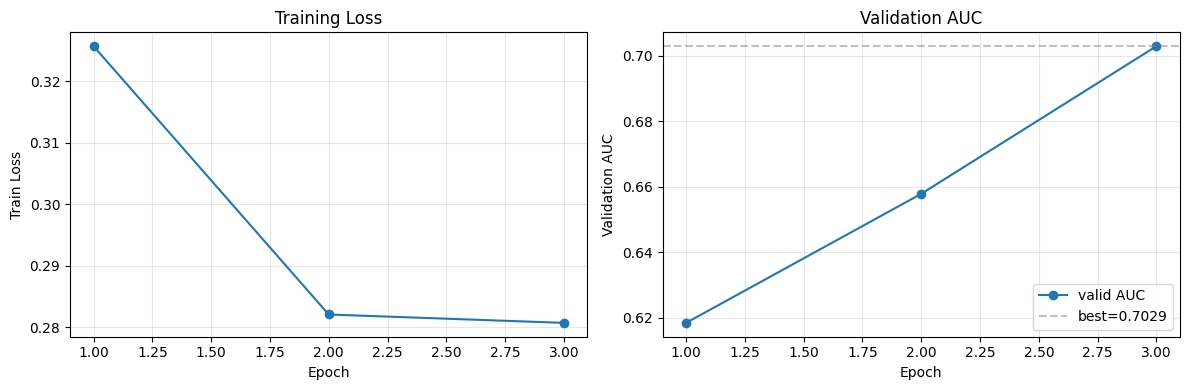

In [11]:
# Per-epoch metrics for the write-up
history_path = logger.artifact_path("ft_transformer_default_history.csv")
history.to_csv(history_path, index=False)
print(f"Saved training history: {history_path}")

# Quick visual
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["epoch"], history["train_loss"], "o-")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Train Loss"); ax[0].set_title("Training Loss")
ax[0].grid(True, alpha=0.3)

ax[1].plot(history["epoch"], history["valid_auc"], "o-", label="valid AUC")
ax[1].axhline(early.best_score, ls="--", color="gray", alpha=0.5, label=f"best={early.best_score:.4f}")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Validation AUC"); ax[1].set_title("Validation AUC")
ax[1].grid(True, alpha=0.3); ax[1].legend()

plt.tight_layout()
plt.savefig(logger.artifact_path("ft_transformer_default_training_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Save model checkpoint

In [12]:
ckpt_path = logger.artifact_path("ft_transformer_default.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "best_valid_auc": float(early.best_score),
    "best_epoch": int(early.best_epoch),
    "config": {
        "n_blocks": 3,
        "d_token": 192,
        "attention_n_heads": 8,
        "attention_dropout": 0.2,
        "ffn_d_hidden_multiplier": 4 / 3,
        "ffn_dropout": 0.1,
        "residual_dropout": 0.0,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "patience": PATIENCE,
        "use_amp": USE_AMP,
    },
    "num_cols": data.num_cols,
    "cat_cols": data.cat_cols,
    "cat_cardinalities": data.cat_cardinalities,
}, ckpt_path)
print(f"Saved checkpoint: {ckpt_path}")

Saved checkpoint: /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_default.pt


## 7. Evaluate

Wrap the trained model in `FTTransformerWrapper`, which exposes
`.predict_proba()` so the existing `report_performance` helper works
unchanged. This means the FT-Transformer row in the summary table uses the
exact same metric computation as LR / RF / XGBoost — no risk of "the deep
learning model used a different metric definition."

The wrapper expects a concatenated DataFrame at call time (it knows which
columns are num vs cat from the lists we pass in).

In [13]:
wrapper = FTTransformerWrapper(
    model=model,
    num_cols=data.num_cols,
    cat_cols=data.cat_cols,
    device=DEVICE,
    batch_size=256,
    use_amp=USE_AMP,
)

# Build concatenated DataFrames matching the wrapper's expected input shape.
# Note we put NUM columns first and CAT after — matches the order in num_cols + cat_cols.
X_train = pd.concat([data.x_num_train, data.x_cat_train], axis=1)
X_valid = pd.concat([data.x_num_valid, data.x_cat_valid], axis=1)
X_test  = pd.concat([data.x_num_test,  data.x_cat_test],  axis=1)

perf_ft_default = report_performance(
    wrapper, X_train, data.y_train, X_valid, data.y_valid, X_test, data.y_test
)

measure_inference_time(
    wrapper, X_test, n_repeats=5,
    logger=logger, model_name="ft_transformer_default",
);

perf_ft_default

  [inference] X has only 2000 rows; using all of them
  [inference] ft_transformer_default: median=434.66ms std=1.33ms (over 5 runs, 2000 samples)


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,6400,517,0.0808,0.708558,0.417115,0.326276,0.194535,0.212257,0.274662
Value,Validation,1600,129,0.0806,0.702894,0.405788,0.302046,0.171471,0.212500,0.263566
Value,Test,2000,161,0.0805,0.673562,0.347124,0.275616,0.160770,0.183575,0.236025


### 7.1 Persist all artifacts

One call to `save_run_artifacts` writes:

* `ft_transformer_default_perf.csv` — train/valid/test metrics
* `ft_transformer_default_predictions_test.npy` — test-set scores
* appends/updates a row in `results/summary_test_metrics_home_credit.csv`

The training history CSV, model checkpoint, and training-curve PNG were saved
separately in Section 6.

In [14]:
save_run_artifacts(
    logger,
    model_name="ft_transformer_default",
    perf_df=perf_ft_default,
    best_params={
        # Manually-set "best" params for this default run; Pass 2 will use Optuna
        "n_blocks": 3, "d_token": 192, "attention_n_heads": 8,
        "attention_dropout": 0.2, "ffn_d_hidden_multiplier": 4 / 3,
        "ffn_dropout": 0.1, "residual_dropout": 0.0,
        "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE, "max_epochs": DEV_MAX_EPOCHS,
        "patience": PATIENCE, "use_amp": USE_AMP,
        "best_valid_auc": float(early.best_score),
        "best_epoch": int(early.best_epoch),
        "trained_epochs": len(history),
        "dev_mode": DEV_MODE,
    },
    test_predictions=wrapper.predict_proba(X_test)[:, 1],
    y_test=data.y_test.values,
    extra_metadata={"dev_mode": DEV_MODE, "trained_epochs": len(history)},
)

  [save] ft_transformer_default: wrote 3 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_default_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_default_predictions_test.npy


{'dataset': 'home_credit',
 'model_name': 'ft_transformer_default',
 'timestamp': '2026-05-21T10:14:14',
 'AUC': 0.6735617858747159,
 'Gini': 0.34712357174943187,
 'KS_Statistic': 0.27561562961236696,
 'AUCPR': 0.16077021927918228,
 'Precision_top10': 0.18357487922705315,
 'Recall_top10': 0.2360248447204969,
 'dev_mode': True,
 'trained_epochs': 3}

## 8. Summary — FT-Transformer joins the leaderboard

Reload the cross-run summary CSV and the per-block timings to see how the
FT-Transformer sanity run compares to the LR / RF / XGBoost rows that were
saved by `01_home_credit_baselines.ipynb`.

If this notebook was run with **DEV_MODE=True**, the FT-Transformer row will
likely be much worse than the tuned baselines — it's a tiny model trained for
a few epochs on a fraction of the data. That's fine: this notebook's job is
to confirm the architecture trains end-to-end. The real comparison happens in
Pass 2 with Optuna tuning.

In [15]:
summary = load_summary(RESULTS_DIR, "home_credit")
summary[[
    "model_name", "AUC", "Gini", "KS_Statistic", "AUCPR",
    "Precision_top10", "Recall_top10",
]]

,model_name,AUC,Gini,KS_Statistic,AUCPR,Precision_top10,Recall_top10
0,lr_default,0.762365,0.524730,0.396683,0.241728,0.272313,0.337362
1,lr_tuned,0.763267,0.526533,0.396435,0.242868,0.274752,0.340383
2,rf_default,0.723839,0.447679,0.340281,0.214968,0.246644,0.318228
3,rf_tuned,0.729130,0.458260,0.339465,0.210351,0.242237,0.300101
4,xgb_default,0.768087,0.536174,0.404768,0.257237,0.281093,0.348238
5,xgb_tuned,0.781593,0.563186,0.423780,0.284842,0.300927,0.372810
6,ft_transformer_default,0.673562,0.347124,0.275616,0.160770,0.183575,0.236025


### Timings — training-time comparison source data

In [16]:
timings = load_timings(ARTIFACTS_DIR)
timings_pivot = (
    timings
    .pivot_table(index="model_name", columns="block", values="seconds", aggfunc="last")
    .round(3)
)
timings_pivot

block,categorical_ablation,imbalance_study,inference_10000,inference_2000,train,tuning_loop
model_name,,,,,,
ft_transformer_cat_ablation,218.212,NaN,NaN,NaN,NaN,NaN
ft_transformer_default,NaN,NaN,2.405,0.435,15.038,NaN
ft_transformer_imbalance,NaN,409.229,NaN,NaN,NaN,NaN
ft_transformer_tuned,NaN,NaN,NaN,NaN,NaN,0.611
lr_default,NaN,NaN,0.018,NaN,18.738,NaN
lr_tuned,NaN,NaN,0.015,NaN,111.598,5649.355
rf_default,NaN,NaN,0.735,NaN,219.281,NaN
rf_tuned,NaN,NaN,0.230,NaN,1585.033,20073.091
xgb_default,NaN,NaN,0.079,NaN,7.686,NaN


---

# Pass 2 — Full Experiments

Sections 1–8 above were the **sanity run**: one FT-Transformer with the
original FT-Transformer paper's
defaults to confirm the architecture trains end-to-end. Pass 2 below runs
the full experimental suite:

| # | Experiment | Purpose |
| :- | :--- | :--- |
| 9 | Imbalance handling mini-study | Pick best loss strategy (BCE / weighted / focal) |
| 10 | Categorical handling ablation | With vs without feature tokenizer |
| 11 | Optuna hyperparameter tuning | 30-trial Bayesian search, SQLite-persisted |
| 12 | Final tuned run | Train best_params, save curves + checkpoint |
| 13 | Hyperparameter sensitivity sweeps | 5 knobs × 4 points → study figures |
| 14 | Sample-size study | 25 / 50 / 75 / 100% of train data |
| 15 | MLP baseline | Same training loop, simpler architecture |
| 16 | Attention map extraction | Per-feature attention vs baseline SHAP |
| 17 | (Optional) Seed variance | 5 seeds — flag-gated for cost |
| 19 | Decision boundary analysis | Axis-aligned vs smooth surfaces (tests the study's core claim) |

Everything from here persists via the same `tracking` module. New rows
accumulate in `results/summary_test_metrics_home_credit.csv`.

> **Run order.** Sections 9 and 10 are mini-studies that **inform** the
> Optuna search in §11. Run them first, decide the winning loss strategy,
> then proceed to tuning.

## Pass 2 — Configuration

Two flags control cost vs accuracy tradeoffs for the expensive experiments.

In [17]:
# Sensitivity sweeps: full-convergence training per point (slow) vs capped (fast)
SENSITIVITY_FULL_EPOCHS = False   # True = up to max_epochs each point; False = use DEV_MAX_EPOCHS

# Seed variance is OPTIONAL — adds ~5x runtime over a single tuned run.
# Run only if your compute budget allows; not required for the core study.
RUN_SEED_VARIANCE = False

# Optuna tuning trials. Default 30 matches the XGBoost search budget in the
# baselines for fair comparison. Drop to 10–15 if compute is tight.
N_TRIALS_FT = 20

# Sensitivity sweep grids (5 knobs)
SWEEP_N_BLOCKS       = [1, 2, 3, 4]
SWEEP_D_TOKEN        = [64, 128, 192, 256]
SWEEP_N_HEADS        = [2, 4, 8, 16]   # filtered per-d_token (must divide)
SWEEP_ATTN_DROPOUT   = [0.0, 0.1, 0.2, 0.4]
SWEEP_LEARNING_RATE  = [1e-5, 3e-5, 1e-4, 3e-4]

# Sample-size study fractions
SAMPLE_SIZE_FRACTIONS = [0.25, 0.50, 0.75, 1.0]

print(f"SENSITIVITY_FULL_EPOCHS = {SENSITIVITY_FULL_EPOCHS}")
print(f"RUN_SEED_VARIANCE       = {RUN_SEED_VARIANCE}")
print(f"N_TRIALS_FT             = {N_TRIALS_FT}")

SENSITIVITY_FULL_EPOCHS = False
RUN_SEED_VARIANCE       = False
N_TRIALS_FT             = 20


## 9. Imbalance handling mini-study

FT-Transformer doesn't have a built-in `scale_pos_weight` like XGBoost. We
compare four strategies on **short runs** (10 epochs each, same architecture),
pick the winner by validation AUC, and use it for all subsequent experiments.

| Strategy | Implementation |
| :--- | :--- |
| Plain BCE | `BCEWithLogitsLoss()` |
| Weighted BCE | `BCEWithLogitsLoss(pos_weight=neg/pos)` |
| Focal γ=1 | Focal loss with γ=1 |
| Focal γ=2 | Focal loss with γ=2 |

We're not searching this inside Optuna — it would confound the architecture
sensitivity narrative. Locking it in first keeps the Optuna study clean.

In [18]:
import torch.nn.functional as F

class FocalLoss(torch.nn.Module):
    """Focal loss for binary classification on logits.

    L = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = -alpha_t * (1 - p_t) ** self.gamma * torch.log(p_t.clamp(min=1e-8))
        return focal.mean()


def train_short(loss_strategy, max_epochs=10, **build_kwargs):
    """Train a fresh FT-Transformer for `max_epochs` with the given loss.

    Returns (best_valid_auc, history_df) — minimal output for the mini-study.
    Each call rebuilds the model so we start from random init.
    """
    set_torch_seed(RANDOM_SEED)
    model = build_ft_transformer(
        n_num_features=len(data.num_cols),
        cat_cardinalities=data.cat_cardinalities,
        **build_kwargs,
    ).to(DEVICE)

    # Loss
    pos_weight_val = None
    custom_loss = None
    if loss_strategy == "weighted_bce":
        pos_count = float(data.y_train.sum())
        neg_count = float(len(data.y_train) - pos_count)
        pos_weight_val = neg_count / pos_count
    elif loss_strategy == "focal_g1":
        custom_loss = FocalLoss(gamma=1.0)
    elif loss_strategy == "focal_g2":
        custom_loss = FocalLoss(gamma=2.0)
    # else: plain BCE (default pos_weight=None inside train_ft_transformer)

    if custom_loss is None:
        # Standard / weighted BCE — delegate to the existing helper
        _, history, early = train_ft_transformer(
            model, train_loader, valid_loader,
            max_epochs=max_epochs,
            learning_rate=1e-4,
            weight_decay=1e-5,
            pos_weight=pos_weight_val,
            patience=max_epochs,  # don't early-stop in mini-study
            use_amp=USE_AMP,
            device=DEVICE,
            verbose=False,
        )
    else:
        # Custom loss path — short reimplementation of the loop
        from src.ft_transformer_utils import train_one_epoch, evaluate, EarlyStopper
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scaler = torch.cuda.amp.GradScaler() if USE_AMP else None
        history_rows = []
        best_auc = -1.0
        for epoch in range(1, max_epochs + 1):
            train_loss = train_one_epoch(
                model, train_loader, optimizer, custom_loss, DEVICE, scaler, USE_AMP
            )
            _, _, valid_auc = evaluate(model, valid_loader, DEVICE, USE_AMP)
            history_rows.append({"epoch": epoch, "train_loss": train_loss, "valid_auc": valid_auc})
            best_auc = max(best_auc, valid_auc)
        history = pd.DataFrame(history_rows)
        early = EarlyStopper(); early.best_score = best_auc

    return early.best_score, history

In [19]:
IMBALANCE_STRATEGIES = ["bce", "weighted_bce", "focal_g1", "focal_g2"]
imbalance_results = []

# Use the FT-Transformer paper's default architecture for the mini-study
# so we isolate the loss effect
build_kwargs_default = dict(
    n_blocks=3, d_token=192, attention_n_heads=8,
    attention_dropout=0.2, ffn_d_hidden_multiplier=4 / 3,
    ffn_dropout=0.1, residual_dropout=0.0,
)

with time_block("imbalance_study", logger, model_name="ft_transformer_imbalance"):
    for strategy in IMBALANCE_STRATEGIES:
        print(f"\n=== Strategy: {strategy} ===")
        best_auc, _ = train_short(
            strategy,
            max_epochs=10 if not DEV_MODE else 3,
            **build_kwargs_default,
        )
        print(f"  Best valid AUC: {best_auc:.5f}")
        imbalance_results.append({"strategy": strategy, "best_valid_auc": best_auc})

imbalance_df = pd.DataFrame(imbalance_results).sort_values("best_valid_auc", ascending=False)
imbalance_df.to_csv(logger.artifact_path("imbalance_study.csv"), index=False)
imbalance_df

  [timer] starting: ft_transformer_imbalance/imbalance_study

=== Strategy: bce ===
  Best valid AUC: 0.71329

=== Strategy: weighted_bce ===
  Best valid AUC: 0.71040

=== Strategy: focal_g1 ===
  Best valid AUC: 0.69199

=== Strategy: focal_g2 ===
  Best valid AUC: 0.69503
  [timer] ft_transformer_imbalance/imbalance_study: 82.41s (1.37 min)


,strategy,best_valid_auc
0,bce,0.713292
1,weighted_bce,0.710401
3,focal_g2,0.695032
2,focal_g1,0.691991


In [20]:
# Lock in the winner for all subsequent experiments
BEST_LOSS_STRATEGY = imbalance_df.iloc[0]["strategy"]
print(f"Winning imbalance strategy: {BEST_LOSS_STRATEGY}")

# Pre-compute pos_weight (used by tuning + final run if strategy uses weighted BCE)
pos_count = float(data.y_train.sum())
neg_count = float(len(data.y_train) - pos_count)
THEORETICAL_POS_WEIGHT = neg_count / pos_count
print(f"Theoretical pos_weight (neg/pos) = {THEORETICAL_POS_WEIGHT:.3f}")

Winning imbalance strategy: bce
Theoretical pos_weight (neg/pos) = 11.379


In [21]:
BEST_LOSS_STRATEGY

'bce'

## 10. Categorical handling ablation

FT-Transformer's headline pitch is that its feature tokenizer handles
numerical and categorical features uniformly. Worth measuring whether that
matters on credit data.

| Run | Description |
| :--- | :--- |
| **A — Standard** | numerical + categorical via FT tokenizer (the default) |
| **B — No categoricals** | treat all features as numerical (categoricals already label-encoded → cast to float) |

If B significantly underperforms A, the tokenizer is doing real work. If
they're comparable, that's also a noteworthy finding ("the tokenizer
doesn't help much on this data — here's why we think so").

Both runs use 10 epochs and the winning loss strategy from §9.

In [22]:
def run_categorical_ablation(use_cat_tokenizer: bool, max_epochs=10):
    """Train one short run with or without the FT categorical tokenizer."""
    set_torch_seed(RANDOM_SEED)
    pos_weight_val = THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None

    if use_cat_tokenizer:
        # Standard FT-Transformer setup
        model = build_ft_transformer(
            n_num_features=len(data.num_cols),
            cat_cardinalities=data.cat_cardinalities,
            **build_kwargs_default,
        ).to(DEVICE)
        loader_train, loader_valid = train_loader, valid_loader
    else:
        # All features as numerical: cast categoricals to float, concat with numerics
        from src.ft_transformer_utils import TabularDataset
        from torch.utils.data import DataLoader

        x_num_train_all = pd.concat(
            [data.x_num_train, data.x_cat_train.astype(np.float32)], axis=1
        )
        x_num_valid_all = pd.concat(
            [data.x_num_valid, data.x_cat_valid.astype(np.float32)], axis=1
        )

        # FT-Transformer requires a non-empty cat tensor; pass a dummy with cardinality 1.
        # All zeros → no information in the categorical channel.
        dummy_train = pd.DataFrame({"_dummy": [0] * len(x_num_train_all)})
        dummy_valid = pd.DataFrame({"_dummy": [0] * len(x_num_valid_all)})

        train_ds_b = TabularDataset(x_num_train_all, dummy_train, data.y_train)
        valid_ds_b = TabularDataset(x_num_valid_all, dummy_valid, data.y_valid)
        loader_train = DataLoader(train_ds_b, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
        loader_valid = DataLoader(valid_ds_b, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0, pin_memory=True)

        model = build_ft_transformer(
            n_num_features=x_num_train_all.shape[1],
            cat_cardinalities=[1],  # dummy single-category cat
            **build_kwargs_default,
        ).to(DEVICE)

    _, history, early = train_ft_transformer(
        model, loader_train, loader_valid,
        max_epochs=max_epochs,
        learning_rate=1e-4, weight_decay=1e-5,
        pos_weight=pos_weight_val,
        patience=max_epochs,
        use_amp=USE_AMP, device=DEVICE,
        verbose=False,
    )
    return early.best_score


with time_block("categorical_ablation", logger, model_name="ft_transformer_cat_ablation"):
    print("Run A: standard (with feature tokenizer for categoricals)")
    auc_with_tok = run_categorical_ablation(use_cat_tokenizer=True, max_epochs=10 if not DEV_MODE else 3)
    print(f"  Best valid AUC: {auc_with_tok:.5f}")

    print("\nRun B: all features as numerical (tokenizer bypassed)")
    auc_no_tok = run_categorical_ablation(use_cat_tokenizer=False, max_epochs=10 if not DEV_MODE else 3)
    print(f"  Best valid AUC: {auc_no_tok:.5f}")

cat_ablation_df = pd.DataFrame([
    {"run": "A_with_tokenizer", "best_valid_auc": auc_with_tok},
    {"run": "B_no_tokenizer",   "best_valid_auc": auc_no_tok},
])
cat_ablation_df["delta_vs_B"] = cat_ablation_df["best_valid_auc"] - auc_no_tok
cat_ablation_df.to_csv(logger.artifact_path("cat_ablation.csv"), index=False)
cat_ablation_df

  [timer] starting: ft_transformer_cat_ablation/categorical_ablation
Run A: standard (with feature tokenizer for categoricals)
  Best valid AUC: 0.71329

Run B: all features as numerical (tokenizer bypassed)
  Best valid AUC: 0.63404
  [timer] ft_transformer_cat_ablation/categorical_ablation: 43.53s (0.73 min)


,run,best_valid_auc,delta_vs_B
0,A_with_tokenizer,0.713292,0.079251
1,B_no_tokenizer,0.634041,0.000000


## 11. Optuna hyperparameter tuning

30-trial Bayesian search with TPE sampler (seeded for reproducibility) and
**MedianPruner** that kills trials underperforming after 3 epochs — saves
roughly 40% of total tuning time.

The study is persisted to a SQLite file on Drive so trials accumulate across
Colab disconnects. If you get disconnected mid-tuning, just re-run this cell
— it picks up from where it left off and continues until `N_TRIALS_FT` trials
are recorded.

### Search space (10 dimensions)

| Param | Range |
| :--- | :--- |
| `n_blocks` | int [1, 4] |
| `d_token` | categorical {64, 128, 192, 256} |
| `attention_n_heads` | categorical, **filtered to divisors of `d_token`** |
| `attention_dropout` | float [0.0, 0.5] |
| `ffn_d_hidden_multiplier` | float [0.66, 2.66] |
| `ffn_dropout` | float [0.0, 0.5] |
| `residual_dropout` | float [0.0, 0.2] |
| `learning_rate` | log-uniform [1e-5, 1e-3] |
| `weight_decay` | log-uniform [1e-6, 1e-3] |
| (loss strategy) | fixed from §9 |

**`attention_n_heads` is constrained by `d_token` divisibility.** For each
sampled `d_token`, we restrict the n_heads choice to the divisors of that
d_token from {2, 4, 8, 16}. This guarantees every trial is valid (no failed
trials) at a small expressivity cost.

In [26]:
N_TRIALS_FT = 6

In [27]:
import optuna
from optuna.pruners import MedianPruner

# Place the study DB next to other artifacts. Persists across Colab sessions.
STUDY_DB_PATH = logger.artifact_path("ft_transformer_optuna_study.db")
STUDY_DB_URL = f"sqlite:///{STUDY_DB_PATH}"
print(f"Optuna study DB: {STUDY_DB_PATH}")


def valid_n_heads_for(d_token, candidates=(2, 4, 8, 16)):
    """Return the n_heads candidates that divide d_token evenly."""
    return [h for h in candidates if d_token % h == 0]


def tune_ft_objective(trial):
    # Architecture — sample d_token first, then constrain n_heads
    n_blocks      = trial.suggest_int("n_blocks", 1, 4)
    d_token       = trial.suggest_categorical("d_token", [64, 128, 192, 256])
    n_heads       = trial.suggest_categorical(
        "attention_n_heads", valid_n_heads_for(d_token)
    )
    attn_dropout  = trial.suggest_float("attention_dropout", 0.0, 0.5)
    ffn_mult      = trial.suggest_float("ffn_d_hidden_multiplier", 0.66, 2.66)
    ffn_dropout   = trial.suggest_float("ffn_dropout", 0.0, 0.5)
    res_dropout   = trial.suggest_float("residual_dropout", 0.0, 0.2)
    lr            = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    wd            = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    set_torch_seed(RANDOM_SEED)
    model = build_ft_transformer(
        n_num_features=len(data.num_cols),
        cat_cardinalities=data.cat_cardinalities,
        n_blocks=n_blocks,
        d_token=d_token,
        attention_n_heads=n_heads,
        attention_dropout=attn_dropout,
        ffn_d_hidden_multiplier=ffn_mult,
        ffn_dropout=ffn_dropout,
        residual_dropout=res_dropout,
    ).to(DEVICE)

    pos_weight_val = THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None
    pw_tensor = torch.tensor([pos_weight_val], device=DEVICE) if pos_weight_val else None
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pw_tensor)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = torch.cuda.amp.GradScaler() if USE_AMP else None

    from src.ft_transformer_utils import train_one_epoch, evaluate, EarlyStopper
    early = EarlyStopper(patience=PATIENCE)

    max_epochs_trial = DEV_MAX_EPOCHS if DEV_MODE else 30
    for epoch in range(1, max_epochs_trial + 1):
        _ = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE, scaler, USE_AMP)
        _, _, valid_auc = evaluate(model, valid_loader, DEVICE, USE_AMP)

        # Report to Optuna and check for pruning
        trial.report(valid_auc, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if early.step(valid_auc, model, epoch):
            break

    print(f"  Trial {trial.number}: best_valid_auc={early.best_score:.5f} "
          f"(d_token={d_token}, n_heads={n_heads}, n_blocks={n_blocks})")
    return early.best_score


study_ft = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    study_name="FTTransformer_HomeCredit_Tuning",
    storage=STUDY_DB_URL,
    load_if_exists=True,
)

trials_done = len([t for t in study_ft.trials if t.state == optuna.trial.TrialState.COMPLETE])
trials_remaining = max(0, N_TRIALS_FT - trials_done)
print(f"Completed trials so far: {trials_done}")
print(f"Trials remaining        : {trials_remaining}")

Optuna study DB: /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_optuna_study.db


[I 2026-05-21 10:17:06,548] Using an existing study with name 'FTTransformer_HomeCredit_Tuning' instead of creating a new one.


Completed trials so far: 6
Trials remaining        : 0


In [28]:
with time_block("tuning_loop", logger, model_name="ft_transformer_tuned"):
    if trials_remaining > 0:
        study_ft.optimize(tune_ft_objective, n_trials=trials_remaining, show_progress_bar=False)
    else:
        print("All trials already complete; skipping optimize()")

print(f"\nBest validation AUC: {study_ft.best_value:.5f}")
print("Best params:")
for k, v in study_ft.best_params.items():
    print(f"  {k}: {v}")

  [timer] starting: ft_transformer_tuned/tuning_loop
All trials already complete; skipping optimize()
  [timer] ft_transformer_tuned/tuning_loop: 0.00s (0.00 min)

Best validation AUC: 0.77619
Best params:
  n_blocks: 3
  d_token: 192
  attention_n_heads: 2
  attention_dropout: 0.29894998940554257
  ffn_d_hidden_multiplier: 2.503748470046234
  ffn_dropout: 0.04424625102595975
  residual_dropout: 0.039196572483829045
  learning_rate: 1.2315571723666024e-05
  weight_decay: 9.462175356461487e-06


## 12. Final tuned FT-Transformer

Train one full-convergence run with the best Optuna params, save curves +
checkpoint, evaluate on test set, persist all artifacts.

In [29]:
best_params_ft = study_ft.best_params
print("Training final FT-Transformer with tuned hyperparameters:")
for k, v in best_params_ft.items():
    print(f"  {k}: {v}")

set_torch_seed(RANDOM_SEED)
model_tuned = build_ft_transformer(
    n_num_features=len(data.num_cols),
    cat_cardinalities=data.cat_cardinalities,
    n_blocks=best_params_ft["n_blocks"],
    d_token=best_params_ft["d_token"],
    attention_n_heads=best_params_ft["attention_n_heads"],
    attention_dropout=best_params_ft["attention_dropout"],
    ffn_d_hidden_multiplier=best_params_ft["ffn_d_hidden_multiplier"],
    ffn_dropout=best_params_ft["ffn_dropout"],
    residual_dropout=best_params_ft["residual_dropout"],
).to(DEVICE)

pos_weight_val = THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None

with time_block("train", logger, model_name="ft_transformer_tuned"):
    model_tuned, history_tuned, early_tuned = train_ft_transformer(
        model_tuned,
        train_loader, valid_loader,
        max_epochs=DEV_MAX_EPOCHS if DEV_MODE else 50,
        learning_rate=best_params_ft["learning_rate"],
        weight_decay=best_params_ft["weight_decay"],
        pos_weight=pos_weight_val,
        patience=PATIENCE,
        use_amp=USE_AMP,
        device=DEVICE,
        verbose=True,
    )

print(f"\nBest validation AUC: {early_tuned.best_score:.5f} (epoch {early_tuned.best_epoch})")

Training final FT-Transformer with tuned hyperparameters:
  n_blocks: 3
  d_token: 192
  attention_n_heads: 2
  attention_dropout: 0.29894998940554257
  ffn_d_hidden_multiplier: 2.503748470046234
  ffn_dropout: 0.04424625102595975
  residual_dropout: 0.039196572483829045
  learning_rate: 1.2315571723666024e-05
  weight_decay: 9.462175356461487e-06
  [timer] starting: ft_transformer_tuned/train
Epoch | Train Loss |  Valid AUC |   Best AUC |   Patience
----------------------------------------------------------------
    1 |     0.4877 |    0.48988 |    0.48988 |    0/10
    2 |     0.2862 |    0.48698 |    0.48988 |    1/10
    3 |     0.2813 |    0.51390 |    0.51390 |    0/10
  [timer] ft_transformer_tuned/train: 13.75s (0.23 min)

Best validation AUC: 0.51390 (epoch 3)


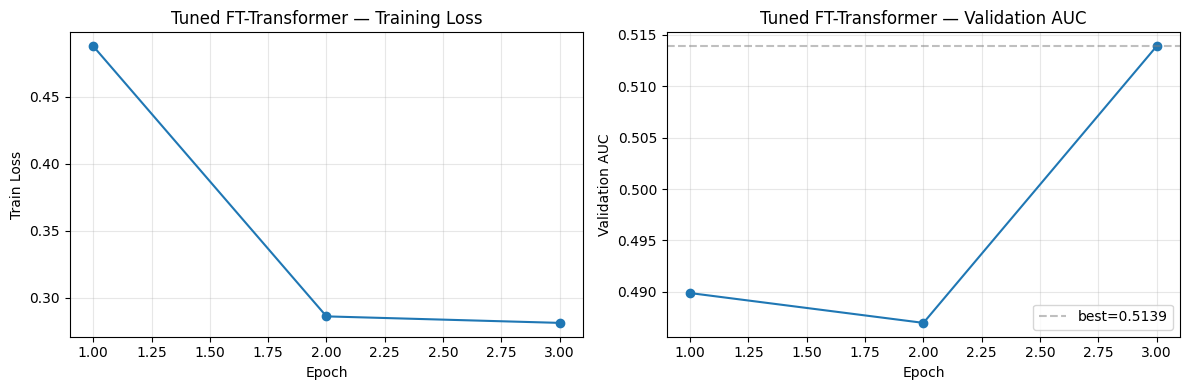

In [30]:
# Persist tuned model
history_tuned.to_csv(logger.artifact_path("ft_transformer_tuned_history.csv"), index=False)
torch.save({
    "model_state_dict": model_tuned.state_dict(),
    "best_valid_auc": float(early_tuned.best_score),
    "best_epoch": int(early_tuned.best_epoch),
    "best_params": best_params_ft,
    "loss_strategy": BEST_LOSS_STRATEGY,
    "num_cols": data.num_cols,
    "cat_cols": data.cat_cols,
    "cat_cardinalities": data.cat_cardinalities,
}, logger.artifact_path("ft_transformer_tuned.pt"))

# Plot training curve
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_tuned["epoch"], history_tuned["train_loss"], "o-")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Train Loss")
ax[0].set_title("Tuned FT-Transformer — Training Loss"); ax[0].grid(True, alpha=0.3)
ax[1].plot(history_tuned["epoch"], history_tuned["valid_auc"], "o-")
ax[1].axhline(early_tuned.best_score, ls="--", color="gray", alpha=0.5,
              label=f"best={early_tuned.best_score:.4f}")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Validation AUC")
ax[1].set_title("Tuned FT-Transformer — Validation AUC"); ax[1].grid(True, alpha=0.3); ax[1].legend()
plt.tight_layout()
plt.savefig(logger.artifact_path("ft_transformer_tuned_training_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# Evaluate tuned model on test set
wrapper_tuned = FTTransformerWrapper(
    model=model_tuned,
    num_cols=data.num_cols,
    cat_cols=data.cat_cols,
    device=DEVICE,
    use_amp=USE_AMP,
)

perf_ft_tuned = report_performance(
    wrapper_tuned, X_train, data.y_train, X_valid, data.y_valid, X_test, data.y_test
)

measure_inference_time(
    wrapper_tuned, X_test, n_repeats=5,
    logger=logger, model_name="ft_transformer_tuned",
);

save_run_artifacts(
    logger,
    model_name="ft_transformer_tuned",
    perf_df=perf_ft_tuned,
    best_params={**best_params_ft, "loss_strategy": BEST_LOSS_STRATEGY,
                 "best_valid_auc": float(early_tuned.best_score),
                 "best_epoch": int(early_tuned.best_epoch),
                 "dev_mode": DEV_MODE},
    study=study_ft,
    test_predictions=wrapper_tuned.predict_proba(X_test)[:, 1],
    y_test=data.y_test.values,
    extra_metadata={"dev_mode": DEV_MODE},
)
perf_ft_tuned

  [inference] X has only 2000 rows; using all of them
  [inference] ft_transformer_tuned: median=485.82ms std=6.05ms (over 5 runs, 2000 samples)
  [save] ft_transformer_tuned: wrote 4 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_tuned_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_tuned_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_tuned_study.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/ft_transformer_tuned_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,6400,517,0.0808,0.504182,0.008365,0.021879,0.084361,0.086093,0.125725
Value,Validation,1600,129,0.0806,0.513854,0.027709,0.066463,0.089084,0.100000,0.139535
Value,Test,2000,161,0.0805,0.502916,0.005833,0.046751,0.086613,0.080569,0.105590


## 13. Hyperparameter sensitivity sweeps

Holding everything else at the tuned best_params, vary one knob at a time and
plot validation AUC vs that knob. This produces the **five** sensitivity
figures for the study's analysis of architectural hyperparameter sensitivity.

The flag `SENSITIVITY_FULL_EPOCHS` at the top of Pass 2 controls training
length per point — `False` (default) caps at `DEV_MAX_EPOCHS`, `True` runs to
full convergence.

**`n_heads` sweep note**: only the divisors of the tuned `d_token` from
{2, 4, 8, 16} are used. So if `d_token=192`, you'll see {2, 4, 8} (16 doesn't
divide 192).

In [32]:
def sweep_one(param_name, values, max_epochs):
    """Vary one hyperparameter, keep others at tuned best. Return DataFrame."""
    rows = []
    base = dict(
        n_blocks=best_params_ft["n_blocks"],
        d_token=best_params_ft["d_token"],
        attention_n_heads=best_params_ft["attention_n_heads"],
        attention_dropout=best_params_ft["attention_dropout"],
        ffn_d_hidden_multiplier=best_params_ft["ffn_d_hidden_multiplier"],
        ffn_dropout=best_params_ft["ffn_dropout"],
        residual_dropout=best_params_ft["residual_dropout"],
    )
    base_lr = best_params_ft["learning_rate"]
    base_wd = best_params_ft["weight_decay"]

    for v in values:
        print(f"  Sweep {param_name}={v}", end="")
        set_torch_seed(RANDOM_SEED)
        kwargs = dict(base)

        # Apply override
        if param_name in kwargs:
            kwargs[param_name] = v
        lr = base_lr if param_name != "learning_rate" else v

        # If sweeping d_token, ensure n_heads still divides it; else skip
        if param_name == "d_token" and kwargs["d_token"] % kwargs["attention_n_heads"] != 0:
            # Replace n_heads with the largest divisor of the swept d_token from {2, 4, 8, 16}
            valid = [h for h in (2, 4, 8, 16) if v % h == 0]
            kwargs["attention_n_heads"] = max(valid) if valid else 2
            print(f"  (auto-set n_heads={kwargs['attention_n_heads']})", end="")

        try:
            model = build_ft_transformer(
                n_num_features=len(data.num_cols),
                cat_cardinalities=data.cat_cardinalities,
                **kwargs,
            ).to(DEVICE)
        except AssertionError as e:
            print(f"  → SKIPPED ({e})")
            continue

        pos_weight_val = THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None
        _, _, early = train_ft_transformer(
            model, sweep_train_loader, valid_loader,
            max_epochs=max_epochs,
            learning_rate=lr,
            weight_decay=base_wd,
            pos_weight=pos_weight_val,
            patience=PATIENCE,
            use_amp=USE_AMP, device=DEVICE, verbose=False,
        )
        print(f"  → valid AUC = {early.best_score:.5f}")
        rows.append({"param": param_name, "value": v, "valid_auc": early.best_score})

    return pd.DataFrame(rows)


# SWEEP_EPOCHS: how many epochs each sweep point trains for.
# This is intentionally separate from DEV_MAX_EPOCHS (fast dev check) and
# SENSITIVITY_FULL_EPOCHS (full convergence). 10-15 epochs is enough to
# rank hyperparameter settings reliably without paying for full convergence.
# Set SENSITIVITY_FULL_EPOCHS = True above to override with 50 epochs.
SWEEP_EPOCHS_CAP = 12    # change this if you want faster (lower) or more accurate (higher) sweeps

SWEEP_MAX_EPOCHS = 50 if SENSITIVITY_FULL_EPOCHS else min(SWEEP_EPOCHS_CAP, DEV_MAX_EPOCHS if DEV_MODE else SWEEP_EPOCHS_CAP)
print(f"Sensitivity sweeps using max_epochs = {SWEEP_MAX_EPOCHS}")

# SWEEP_DATA_FRACTION: subsample training data for sweeps to speed things up.
# Relative ranking of hyperparameter settings is preserved at 30-40% of data.
# Set to 1.0 to use the full training set for sweeps.
SWEEP_DATA_FRACTION = 0.35   # ~35% of training data — fast + reliable ranking

if SWEEP_DATA_FRACTION < 1.0 and not DEV_MODE:
    from src.ft_transformer_utils import TabularDataset
    from torch.utils.data import DataLoader
    import math
    n_sweep = int(len(data.y_train) * SWEEP_DATA_FRACTION)
    # Stratified subsample
    from sklearn.model_selection import train_test_split as _tts
    idx_sweep, _ = _tts(
        range(len(data.y_train)),
        train_size=n_sweep,
        stratify=data.y_train.values,
        random_state=RANDOM_SEED,
    )
    sweep_train_ds = TabularDataset(
        data.x_num_train.iloc[idx_sweep],
        data.x_cat_train.iloc[idx_sweep],
        data.y_train.iloc[idx_sweep],
    )
    sweep_train_loader = DataLoader(
        sweep_train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True,
    )
    print(f"Sweep train loader: {n_sweep:,} samples ({SWEEP_DATA_FRACTION:.0%} of training data)")
else:
    sweep_train_loader = train_loader
    print(f"Sweep train loader: full training set ({len(data.y_train):,} samples)")

# For n_heads, filter to divisors of the tuned d_token
tuned_d_token = best_params_ft["d_token"]
n_heads_values = [h for h in SWEEP_N_HEADS if tuned_d_token % h == 0]
print(f"n_heads sweep values (must divide d_token={tuned_d_token}): {n_heads_values}")

sweep_results = []
with time_block("sensitivity_sweeps", logger, model_name="ft_transformer_sweeps"):
    print("\nSweep 1/5: n_blocks")
    sweep_results.append(sweep_one("n_blocks", SWEEP_N_BLOCKS, SWEEP_MAX_EPOCHS))
    print("\nSweep 2/5: d_token")
    sweep_results.append(sweep_one("d_token", SWEEP_D_TOKEN, SWEEP_MAX_EPOCHS))
    print("\nSweep 3/5: attention_n_heads")
    sweep_results.append(sweep_one("attention_n_heads", n_heads_values, SWEEP_MAX_EPOCHS))
    print("\nSweep 4/5: attention_dropout")
    sweep_results.append(sweep_one("attention_dropout", SWEEP_ATTN_DROPOUT, SWEEP_MAX_EPOCHS))
    print("\nSweep 5/5: learning_rate")
    sweep_results.append(sweep_one("learning_rate", SWEEP_LEARNING_RATE, SWEEP_MAX_EPOCHS))

sweep_df = pd.concat(sweep_results, ignore_index=True)
sweep_df.to_csv(logger.artifact_path("sensitivity_sweeps.csv"), index=False)
sweep_df

Sensitivity sweeps using max_epochs = 3
Sweep train loader: full training set (6,400 samples)
n_heads sweep values (must divide d_token=192): [2, 4, 8, 16]
  [timer] starting: ft_transformer_sweeps/sensitivity_sweeps

Sweep 1/5: n_blocks
  Sweep n_blocks=1  → valid AUC = 0.54513
  Sweep n_blocks=2  → valid AUC = 0.57233
  Sweep n_blocks=3  → valid AUC = 0.51390
  Sweep n_blocks=4  → valid AUC = 0.57836

Sweep 2/5: d_token
  Sweep d_token=64  → valid AUC = 0.50303
  Sweep d_token=128  → valid AUC = 0.53993
  Sweep d_token=192  → valid AUC = 0.51390
  Sweep d_token=256  → valid AUC = 0.66603

Sweep 3/5: attention_n_heads
  Sweep attention_n_heads=2  → valid AUC = 0.51390
  Sweep attention_n_heads=4  → valid AUC = 0.53010
  Sweep attention_n_heads=8  → valid AUC = 0.50095
  Sweep attention_n_heads=16  → valid AUC = 0.50272

Sweep 4/5: attention_dropout
  Sweep attention_dropout=0.0  → valid AUC = 0.51202
  Sweep attention_dropout=0.1  → valid AUC = 0.51059
  Sweep attention_dropout=0.2  →

,param,value,valid_auc
0,n_blocks,1.00000,0.545128
1,n_blocks,2.00000,0.572329
2,n_blocks,3.00000,0.513899
3,n_blocks,4.00000,0.578360
4,d_token,64.00000,0.503028
5,d_token,128.00000,0.539927
6,d_token,192.00000,0.513899
7,d_token,256.00000,0.666032
8,attention_n_heads,2.00000,0.513899
9,attention_n_heads,4.00000,0.530099


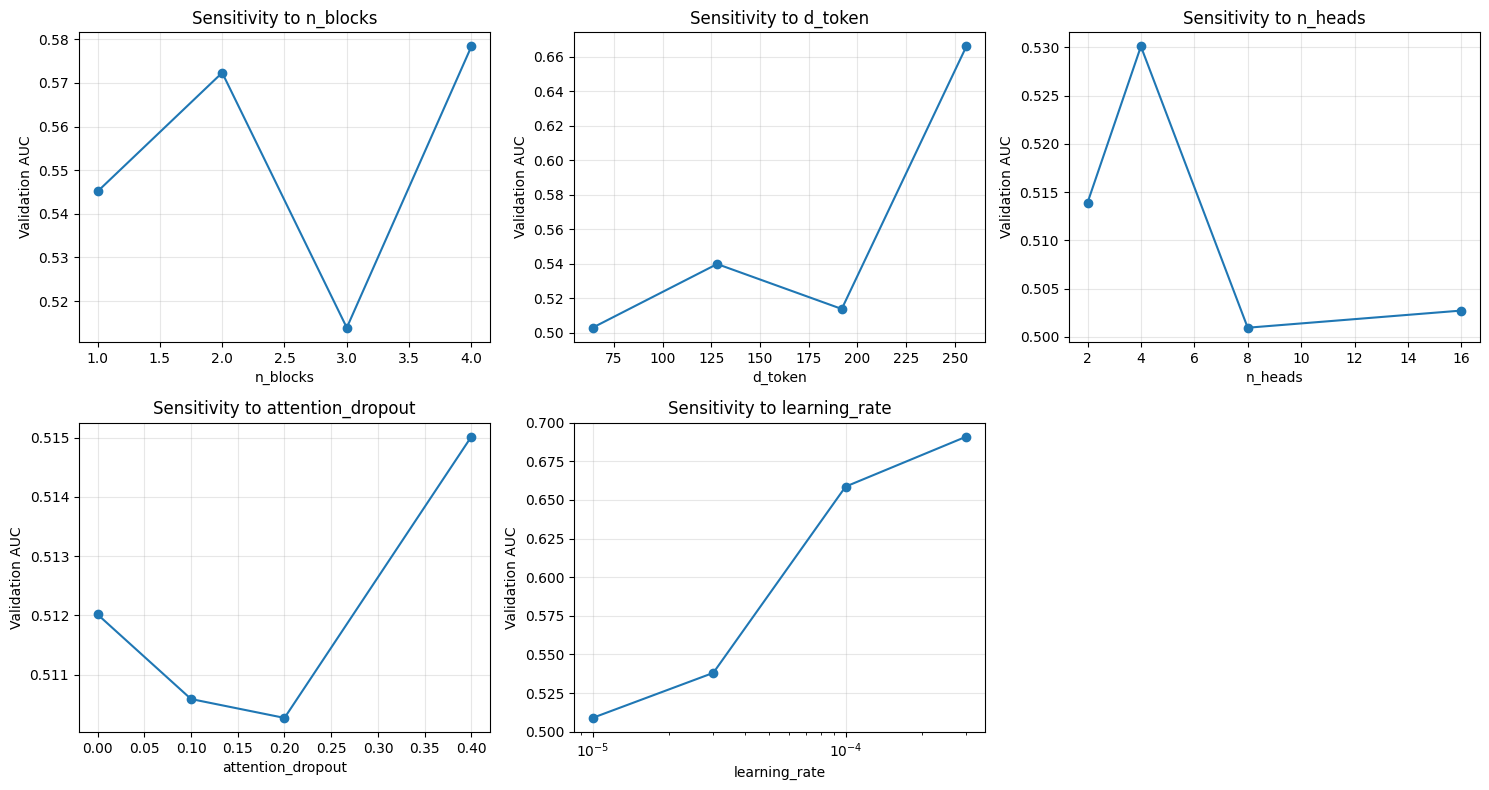

In [33]:
# Plot all five sweeps
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sweeps_to_plot = [
    ("n_blocks",          "n_blocks",          False),
    ("d_token",           "d_token",           False),
    ("attention_n_heads", "n_heads",           False),
    ("attention_dropout", "attention_dropout", False),
    ("learning_rate",     "learning_rate",     True),
]
for ax, (param, label, log) in zip(axes.flat, sweeps_to_plot):
    sub = sweep_df[sweep_df["param"] == param]
    ax.plot(sub["value"], sub["valid_auc"], "o-")
    if log:
        ax.set_xscale("log")
    ax.set_xlabel(label); ax.set_ylabel("Validation AUC")
    ax.set_title(f"Sensitivity to {label}")
    ax.grid(True, alpha=0.3)

# Hide the 6th (empty) subplot
axes.flat[5].axis("off")

plt.tight_layout()
plt.savefig(logger.artifact_path("sensitivity_sweeps.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14. Sample-size study

How does FT-Transformer scale with training data? Train the tuned config on
25 / 50 / 75 / 100% of the training set (validation and test sets unchanged)
and plot test AUC vs n_train.

The folk wisdom "deep learning needs more data than trees" — measuring it
on credit data is a worthwhile result for the study.

In [34]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split as tts


def train_on_fraction(fraction, max_epochs):
    """Train tuned FT-Transformer on `fraction` of training data; return test AUC."""
    # Stratified subsample of train indices
    if fraction < 1.0:
        idx_subset, _ = tts(
            np.arange(len(data.y_train)),
            train_size=fraction,
            stratify=data.y_train.values,
            random_state=RANDOM_SEED,
        )
    else:
        idx_subset = np.arange(len(data.y_train))

    from src.ft_transformer_utils import TabularDataset
    from torch.utils.data import DataLoader

    train_ds_sub = TabularDataset(
        data.x_num_train.iloc[idx_subset],
        data.x_cat_train.iloc[idx_subset],
        data.y_train.iloc[idx_subset],
    )
    train_loader_sub = DataLoader(
        train_ds_sub, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True
    )

    set_torch_seed(RANDOM_SEED)
    model_s = build_ft_transformer(
        n_num_features=len(data.num_cols),
        cat_cardinalities=data.cat_cardinalities,
        n_blocks=best_params_ft["n_blocks"],
        d_token=best_params_ft["d_token"],
        attention_n_heads=best_params_ft["attention_n_heads"],
        attention_dropout=best_params_ft["attention_dropout"],
        ffn_d_hidden_multiplier=best_params_ft["ffn_d_hidden_multiplier"],
        ffn_dropout=best_params_ft["ffn_dropout"],
        residual_dropout=best_params_ft["residual_dropout"],
    ).to(DEVICE)

    pos_weight_val = THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None
    model_s, _, _ = train_ft_transformer(
        model_s,
        train_loader_sub, valid_loader,
        max_epochs=max_epochs,
        learning_rate=best_params_ft["learning_rate"],
        weight_decay=best_params_ft["weight_decay"],
        pos_weight=pos_weight_val,
        patience=PATIENCE,
        use_amp=USE_AMP, device=DEVICE, verbose=False,
    )

    wrapper_s = FTTransformerWrapper(
        model_s, data.num_cols, data.cat_cols, device=DEVICE, use_amp=USE_AMP
    )
    test_proba = wrapper_s.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(data.y_test, test_proba)
    return len(idx_subset), test_auc


sample_size_rows = []
SAMPLE_SIZE_MAX_EPOCHS = DEV_MAX_EPOCHS if DEV_MODE else 30

with time_block("sample_size_study", logger, model_name="ft_transformer_sample_size"):
    for frac in SAMPLE_SIZE_FRACTIONS:
        print(f"\nFraction: {frac}")
        n_used, test_auc = train_on_fraction(frac, max_epochs=SAMPLE_SIZE_MAX_EPOCHS)
        print(f"  n_train = {n_used:,}  →  test AUC = {test_auc:.5f}")
        sample_size_rows.append({"fraction": frac, "n_train": n_used, "test_auc": test_auc})

sample_size_df = pd.DataFrame(sample_size_rows)
sample_size_df.to_csv(logger.artifact_path("sample_size_study.csv"), index=False)
sample_size_df

  [timer] starting: ft_transformer_sample_size/sample_size_study

Fraction: 0.25
  n_train = 1,600  →  test AUC = 0.50237

Fraction: 0.5
  n_train = 3,200  →  test AUC = 0.47054

Fraction: 0.75
  n_train = 4,800  →  test AUC = 0.46070

Fraction: 1.0
  n_train = 6,400  →  test AUC = 0.50292
  [timer] ft_transformer_sample_size/sample_size_study: 38.70s (0.64 min)


,fraction,n_train,test_auc
0,0.25,1600,0.502368
1,0.50,3200,0.470543
2,0.75,4800,0.460701
3,1.00,6400,0.502916


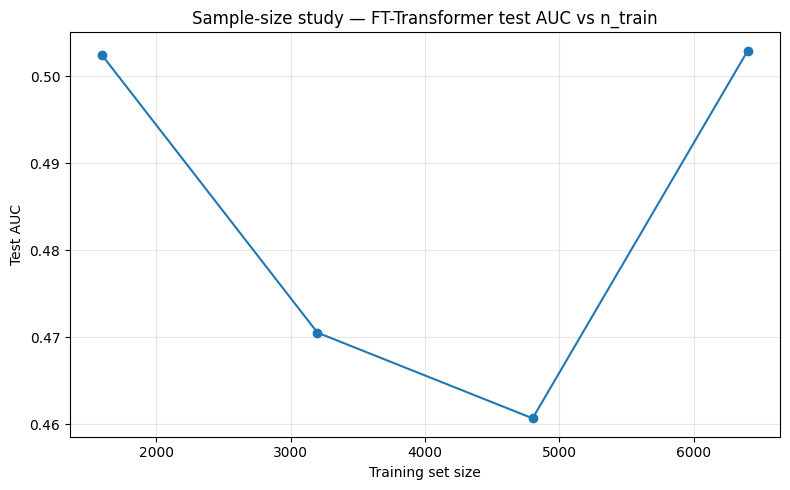

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(sample_size_df["n_train"], sample_size_df["test_auc"], "o-")
plt.xlabel("Training set size")
plt.ylabel("Test AUC")
plt.title("Sample-size study — FT-Transformer test AUC vs n_train")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(logger.artifact_path("sample_size_study.png"), dpi=150, bbox_inches="tight")
plt.show()

## 15. MLP baseline

A simpler tabular DL baseline — isolates "transformer attention" from "deep
learning per se". Uses `rtdl_revisiting_models.MLP` with a similar parameter
count, same training loop, same loss strategy.

If FT-Transformer beats MLP by a meaningful margin, the attention mechanism
is doing real work. If they're comparable, the study's contribution narrows
to "the FT tokenization strategy" rather than "transformers for tabular
data."

In [36]:
from rtdl_revisiting_models import MLP


class MLPWithEmbeddings(torch.nn.Module):
    """MLP that takes (x_num, x_cat) like FT-Transformer.

    Categorical features go through nn.Embedding lookup, are flattened, then
    concatenated with numerics before the MLP forward pass. This matches the
    interface used by train_ft_transformer / FTTransformerWrapper.
    """
    def __init__(self, n_num_features, cat_cardinalities, d_layers, dropout, d_out=1, d_embedding=8):
        super().__init__()
        self.cat_embeddings = torch.nn.ModuleList([
            torch.nn.Embedding(card, d_embedding) for card in cat_cardinalities
        ])
        d_in = n_num_features + d_embedding * len(cat_cardinalities)
        self.mlp = MLP(
            d_in=d_in,
            d_out=d_out,
            n_blocks=len(d_layers),
            d_block=d_layers[0] if d_layers else 256,
            dropout=dropout,
        )

    def forward(self, x_num, x_cat):
        cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
        x = torch.cat([x_num] + cat_embs, dim=1) if cat_embs else x_num
        return self.mlp(x)


# Match FT-Transformer parameter count roughly: 3 hidden layers of 256
MLP_LAYERS = [256, 256, 256]
MLP_DROPOUT = 0.1
MLP_LR = 1e-3
MLP_WD = 1e-5
MLP_MAX_EPOCHS = DEV_MAX_EPOCHS if DEV_MODE else 30

set_torch_seed(RANDOM_SEED)
mlp_model = MLPWithEmbeddings(
    n_num_features=len(data.num_cols),
    cat_cardinalities=data.cat_cardinalities,
    d_layers=MLP_LAYERS,
    dropout=MLP_DROPOUT,
).to(DEVICE)

mlp_param_count = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
ft_param_count  = sum(p.numel() for p in model_tuned.parameters() if p.requires_grad)
print(f"MLP parameters         : {mlp_param_count:,}")
print(f"FT-Transformer (tuned) : {ft_param_count:,}")

with time_block("train", logger, model_name="mlp_baseline"):
    mlp_model, mlp_history, mlp_early = train_ft_transformer(
        mlp_model, train_loader, valid_loader,
        max_epochs=MLP_MAX_EPOCHS,
        learning_rate=MLP_LR,
        weight_decay=MLP_WD,
        pos_weight=THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None,
        patience=PATIENCE,
        use_amp=USE_AMP, device=DEVICE, verbose=True,
    )

print(f"\nMLP best valid AUC: {mlp_early.best_score:.5f}")

MLP parameters         : 236,353
FT-Transformer (tuned) : 1,420,801
  [timer] starting: mlp_baseline/train
Epoch | Train Loss |  Valid AUC |   Best AUC |   Patience
----------------------------------------------------------------
    1 |     0.3468 |    0.70292 |    0.70292 |    0/10
    2 |     0.2542 |    0.72868 |    0.72868 |    0/10
    3 |     0.2365 |    0.74582 |    0.74582 |    0/10
  [timer] mlp_baseline/train: 0.71s (0.01 min)

MLP best valid AUC: 0.74582


In [37]:
wrapper_mlp = FTTransformerWrapper(
    model=mlp_model,
    num_cols=data.num_cols,
    cat_cols=data.cat_cols,
    device=DEVICE,
    use_amp=USE_AMP,
)
perf_mlp = report_performance(
    wrapper_mlp, X_train, data.y_train, X_valid, data.y_valid, X_test, data.y_test
)
measure_inference_time(
    wrapper_mlp, X_test, n_repeats=5,
    logger=logger, model_name="mlp_baseline",
);
save_run_artifacts(
    logger,
    model_name="mlp_baseline",
    perf_df=perf_mlp,
    best_params={
        "d_layers": MLP_LAYERS, "dropout": MLP_DROPOUT, "lr": MLP_LR, "wd": MLP_WD,
        "param_count": mlp_param_count,
        "best_valid_auc": float(mlp_early.best_score),
    },
    test_predictions=wrapper_mlp.predict_proba(X_test)[:, 1],
    y_test=data.y_test.values,
    extra_metadata={"dev_mode": DEV_MODE},
)
perf_mlp

  [inference] X has only 2000 rows; using all of them
  [inference] mlp_baseline: median=6.00ms std=0.27ms (over 5 runs, 2000 samples)
  [save] mlp_baseline: wrote 3 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/mlp_baseline_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/mlp_baseline_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/mlp_baseline_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,6400,517,0.0808,0.851141,0.702282,0.540978,0.391112,0.367188,0.454545
Value,Validation,1600,129,0.0806,0.745825,0.491650,0.390148,0.218480,0.243750,0.302326
Value,Test,2000,161,0.0805,0.728125,0.456250,0.348701,0.188590,0.218905,0.273292


## 16. Attention map extraction

FT-Transformer's selling point includes interpretability via attention
weights. We extract per-feature attention scores from the **last block's**
attention layer of the tuned model and compare with XGBoost SHAP.

### Why this needs care

`rtdl_revisiting_models` applies a **prefix-token optimization** in the final
transformer block: since only the CLS token's representation is consumed by
the output head, the block computes `W_q` **only on the CLS token**
(`[B, 1, d]`), while `W_k` / `W_v` still process the full token sequence
(`[B, n_features+1, d]`). Hooking the parent attention module captures the
already-sliced 1-token input — useless for a per-feature attention map.

### Method

1. Register a `forward_pre_hook` on **`W_k`** (not the parent attention
   module). `W_k` always sees the full token sequence `[B, T, d]` where
   `T = n_features + 1`.
2. Manually apply `W_q` to the CLS token (`x[:, [0], :]`) and `W_k` to the
   full sequence — using the model's own learned weights.
3. Reshape into multi-head form, compute `softmax(Q Kᵀ / √d_head)`. Result is
   `[B, n_heads, 1, T]` — the CLS token's attention to every token.
4. Drop the CLS self-attention (position 0); the remaining `T-1` values are
   per-feature attention scores.
5. Aggregate over 8 test batches; compare top-10 with XGBoost SHAP top-10.

> **Caveat.** Attention is not a strict proxy for feature importance — it
> shows information routing, not causal contribution. We compare *ranks*
> against SHAP rather than claiming attention "explains" predictions.

In [38]:
# Locate the last block's attention module.
# rtdl structure: model.backbone.blocks[-1].attention
last_block = model_tuned.backbone.blocks[-1]

attn_module = None
for name in ("attention", "attn", "self_attention", "mha"):
    if hasattr(last_block, name):
        attn_module = getattr(last_block, name)
        print(f"Found attention module at last_block.{name}: {type(attn_module).__name__}")
        break

if attn_module is None:
    print("Could not auto-locate attention module. Last block structure:")
    print(last_block)
    raise RuntimeError("Update the attribute name above based on the structure shown.")

# This version of rtdl_revisiting_models does not expose n_heads as an
# attribute, so we pull it from the tuned config (the source of truth anyway).
N_HEADS = best_params_ft["attention_n_heads"]
D_TOKEN = attn_module.W_q.out_features
D_HEAD = D_TOKEN // N_HEADS

assert D_TOKEN % N_HEADS == 0, (
    f"d_token ({D_TOKEN}) not divisible by n_heads ({N_HEADS}) - "
    f"model/config mismatch."
)

print(f"  W_q: {attn_module.W_q.in_features} -> {D_TOKEN}")
print(f"  W_k: {attn_module.W_k.in_features} -> {D_TOKEN}")
print(f"  n_heads: {N_HEADS}  (from best_params_ft)")
print(f"  d_head:  {D_HEAD}")

Found attention module at last_block.attention: MultiheadAttention
  W_q: 192 -> 192
  W_k: 192 -> 192
  n_heads: 2  (from best_params_ft)
  d_head:  96


In [39]:
import math

# Hook W_k (NOT the parent attention module). In the final block, rtdl's
# prefix-token optimization slices the input to W_q so it sees only the CLS
# token. W_k still sees the full sequence - that is the tensor we need.
attn_input_capture = {}

def pre_hook(module, inputs):
    attn_input_capture["x_full"] = inputs[0].detach()

handle = attn_module.W_k.register_forward_pre_hook(pre_hook)

N_BATCHES_FOR_ATTENTION = 8
all_attention_scores = []

model_tuned.eval()
with torch.no_grad():
    test_iter = iter(test_loader)
    for batch_idx in range(N_BATCHES_FOR_ATTENTION):
        try:
            batch = next(test_iter)
        except StopIteration:
            break
        x_num_b, x_cat_b, _ = batch
        x_num_b = x_num_b.to(DEVICE)
        x_cat_b = x_cat_b.to(DEVICE)

        # Forward - pre_hook on W_k captures the full [B, T, d] input
        _ = model_tuned(x_num_b, x_cat_b)

        x_full = attn_input_capture["x_full"]    # [B, T, d], T = n_features + 1
        B, T, d = x_full.shape

        # CLS token is at position 0 (rtdl _CLSEmbedding prepends it).
        # Apply W_q to just the CLS token, W_k to the full sequence.
        q = attn_module.W_q(x_full[:, [0], :])   # [B, 1, d]
        k = attn_module.W_k(x_full)              # [B, T, d]

        # Reshape to multi-head form
        q = q.view(B, 1, N_HEADS, D_HEAD).transpose(1, 2)   # [B, n_heads, 1, d_head]
        k = k.view(B, T, N_HEADS, D_HEAD).transpose(1, 2)   # [B, n_heads, T, d_head]

        # Scaled dot-product attention: [B, n_heads, 1, T]
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(D_HEAD)
        attn = torch.softmax(scores, dim=-1)

        # Squeeze the singleton query dim -> [B, n_heads, T], then mean over batch+heads
        cls_attn = attn.squeeze(2).mean(dim=(0, 1))   # [T]
        all_attention_scores.append(cls_attn.cpu().numpy())

        if batch_idx == 0:
            print(f"Captured x_full shape: {tuple(x_full.shape)}")
            print(f"Attention shape after softmax: {tuple(attn.shape)}")
            print(f"CLS self-attention (position 0): {cls_attn[0].item():.4f}")

handle.remove()

# Average across batches
attn_scores_all_tokens = np.stack(all_attention_scores).mean(axis=0)
print(f"\nAggregated over {len(all_attention_scores)} batches")
print(f"Token positions: {len(attn_scores_all_tokens)}")

# Drop CLS self-attention (position 0); keep the real features
attn_scores_features = attn_scores_all_tokens[1:]

# rtdl tokenizes continuous features first, then categorical
feature_names = list(data.num_cols) + list(data.cat_cols)

if len(attn_scores_features) != len(feature_names):
    print(f"WARNING: length mismatch - {len(attn_scores_features)} attention scores "
          f"vs {len(feature_names)} feature names. Truncating to min.")
    n = min(len(attn_scores_features), len(feature_names))
    attn_scores_features = attn_scores_features[:n]
    feature_names = feature_names[:n]

attn_feature_scores = (
    pd.DataFrame({"Feature": feature_names, "Attention_Score": attn_scores_features})
    .sort_values("Attention_Score", ascending=False)
    .reset_index(drop=True)
)
attn_feature_scores.to_csv(logger.artifact_path("attention_importance.csv"), index=False)

# Context: uniform baseline
uniform = 1.0 / len(attn_scores_all_tokens)
top_score = attn_feature_scores["Attention_Score"].iloc[0]
print(f"\nUniform baseline (1/n_tokens): {uniform:.4f}")
print(f"Top feature attention: {top_score:.4f} ({100 * top_score / uniform - 100:+.0f}% vs uniform)")
print("\nTop 20 features by attention score:")
print(attn_feature_scores.head(20).to_string(index=False))

Captured x_full shape: (512, 306, 192)
Attention shape after softmax: (512, 2, 1, 306)
CLS self-attention (position 0): 0.0025

Aggregated over 4 batches
Token positions: 306

Uniform baseline (1/n_tokens): 0.0033
Top feature attention: 0.0052 (+60% vs uniform)

Top 20 features by attention score:
                                        Feature  Attention_Score
                             NAME_CONTRACT_TYPE         0.005238
                   NAME_CASH_LOAN_PURPOSE_Hobby         0.005151
                                FLAG_DOCUMENT_7         0.005127
                               FLAG_DOCUMENT_20         0.004991
                   CREDIT_TYPE_Interbank credit         0.004655
            NAME_CASH_LOAN_PURPOSE_Urgent needs         0.004574
              NAME_CONTRACT_STATUS_Unused offer         0.004553
                                APARTMENTS_MODE         0.004500
                    NAME_GOODS_CATEGORY_Fitness         0.004460
                         NAME_CONTRACT_TYPE_XNA    

In [40]:
# Per-head attention analysis - reveals specialization that mean-aggregation hides
from scipy.stats import entropy

attn_per_head_capture = {}

def pre_hook_ph(module, inputs):
    attn_per_head_capture["x_full"] = inputs[0].detach()

handle_ph = attn_module.W_k.register_forward_pre_hook(pre_hook_ph)

per_head_scores = []   # one [N_HEADS, T] array per batch
model_tuned.eval()
with torch.no_grad():
    test_iter = iter(test_loader)
    for batch_idx in range(N_BATCHES_FOR_ATTENTION):
        try:
            batch = next(test_iter)
        except StopIteration:
            break
        x_num_b, x_cat_b, _ = batch
        x_num_b = x_num_b.to(DEVICE)
        x_cat_b = x_cat_b.to(DEVICE)
        _ = model_tuned(x_num_b, x_cat_b)

        x_full = attn_per_head_capture["x_full"]
        B, T, d = x_full.shape
        q = attn_module.W_q(x_full[:, [0], :]).view(B, 1, N_HEADS, D_HEAD).transpose(1, 2)
        k = attn_module.W_k(x_full).view(B, T, N_HEADS, D_HEAD).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(D_HEAD)
        attn = torch.softmax(scores, dim=-1).squeeze(2)   # [B, n_heads, T]
        per_head_scores.append(attn.mean(dim=0).cpu().numpy())   # [n_heads, T]

handle_ph.remove()

per_head_avg = np.stack(per_head_scores).mean(axis=0)   # [N_HEADS, T]
per_head_features = per_head_avg[:, 1:]                 # drop CLS column

feature_names = list(data.num_cols) + list(data.cat_cols)
n = min(per_head_features.shape[1], len(feature_names))
per_head_features = per_head_features[:, :n]
feature_names = feature_names[:n]

head_cols = [f"head_{h}" for h in range(N_HEADS)]
per_head_df = pd.DataFrame(per_head_features.T, index=feature_names, columns=head_cols)
per_head_df["mean"] = per_head_df[head_cols].mean(axis=1)
per_head_df["max"] = per_head_df[head_cols].max(axis=1)
per_head_df = per_head_df.sort_values("max", ascending=False)
per_head_df.to_csv(logger.artifact_path("attention_per_head.csv"))

uniform = 1.0 / per_head_avg.shape[1]
print("Top-5 features each head attends to most:\n")
for h in range(N_HEADS):
    col = f"head_{h}"
    top = per_head_df[[col]].sort_values(col, ascending=False).head(5)
    pct = 100 * top[col].iloc[0] / uniform
    print(f"Head {h}  (top feature {pct:.0f}% of uniform):")
    for feat, score in top[col].items():
        print(f"  {feat:25s}  {score:.4f}")
    print()

print(f"Per-head attention entropy (uniform baseline = {np.log(per_head_avg.shape[1]):.3f}; "
      f"lower = more focused):")
for h in range(N_HEADS):
    dist = per_head_avg[h] / per_head_avg[h].sum()
    print(f"  Head {h}: {entropy(dist):.3f}")

Top-5 features each head attends to most:

Head 0  (top feature 260% of uniform):
  NAME_CASH_LOAN_PURPOSE_Hobby  0.0085
  NAME_GOODS_CATEGORY_Direct Sales  0.0060
  NONLIVINGAREA_AVG          0.0059
  NAME_CONTRACT_TYPE_XNA     0.0057
  FLAG_DOCUMENT_19           0.0057

Head 1  (top feature 239% of uniform):
  FLAG_DOCUMENT_7            0.0078
  NAME_CONTRACT_TYPE         0.0064
  CREDIT_TYPE_Interbank credit  0.0062
  SK_DPD_x                   0.0062
  LIVINGAREA_AVG             0.0062

Per-head attention entropy (uniform baseline = 5.724; lower = more focused):
  Head 0: 5.683
  Head 1: 5.683


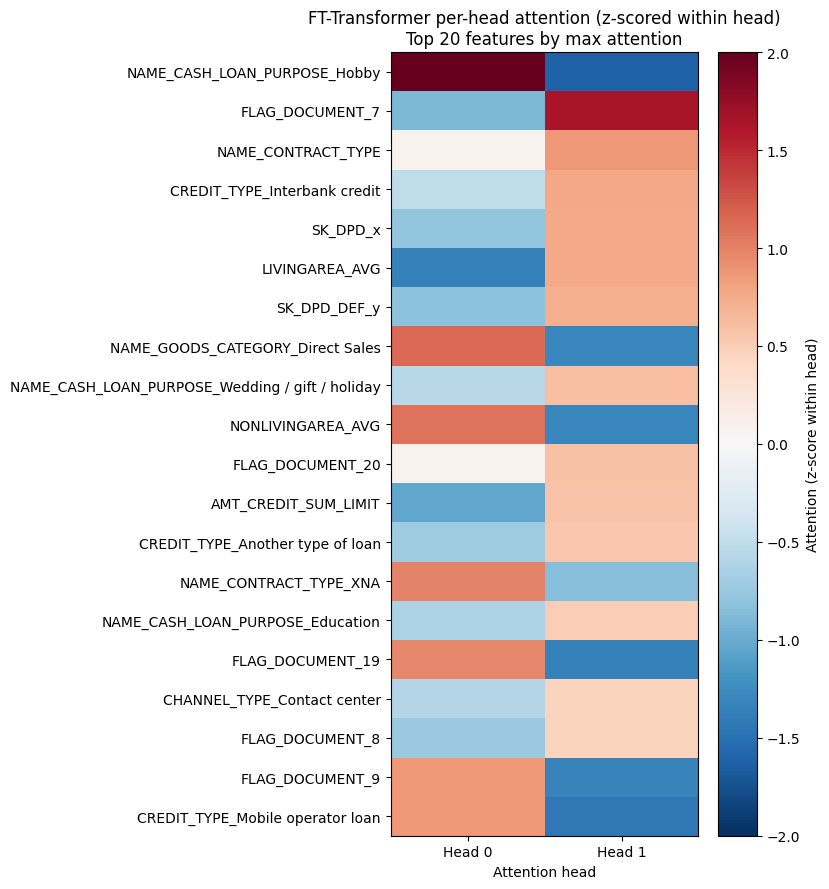

In [41]:
# Per-head attention heatmap (z-scored within each head so relative
# specialization is visible despite near-uniform absolute values)
top20 = per_head_df.head(20)
head_cols = [f"head_{h}" for h in range(N_HEADS)]
matrix = top20[head_cols].values
matrix_z = (matrix - matrix.mean(axis=0, keepdims=True)) / (matrix.std(axis=0, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(matrix_z, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.set_xticks(range(N_HEADS))
ax.set_xticklabels([f"Head {h}" for h in range(N_HEADS)])
ax.set_xlabel("Attention head")
ax.set_title("FT-Transformer per-head attention (z-scored within head)\n"
             "Top 20 features by max attention")
plt.colorbar(im, ax=ax, label="Attention (z-score within head)")
plt.tight_layout()
plt.savefig(logger.artifact_path("attention_per_head_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

Top-10 overlap: 0/10 features
  Both methods agree on: []

                            Feature  SHAP_rank  Attention_rank Both_top10
                       EXT_SOURCE_2        1.0             NaN           
                       EXT_SOURCE_3        2.0             NaN           
                       EXT_SOURCE_1        3.0             NaN           
                      AMT_ANNUITY_x        4.0             NaN           
                        CODE_GENDER        5.0             NaN           
                        AMT_PAYMENT        6.0             NaN           
                      DAYS_EMPLOYED        7.0             NaN           
              CNT_INSTALMENT_FUTURE        8.0             NaN           
                        CNT_PAYMENT        9.0             NaN           
                  AMT_GOODS_PRICE_x       10.0             NaN           
                 NAME_CONTRACT_TYPE        NaN             1.0           
       NAME_CASH_LOAN_PURPOSE_Hobby        NaN       

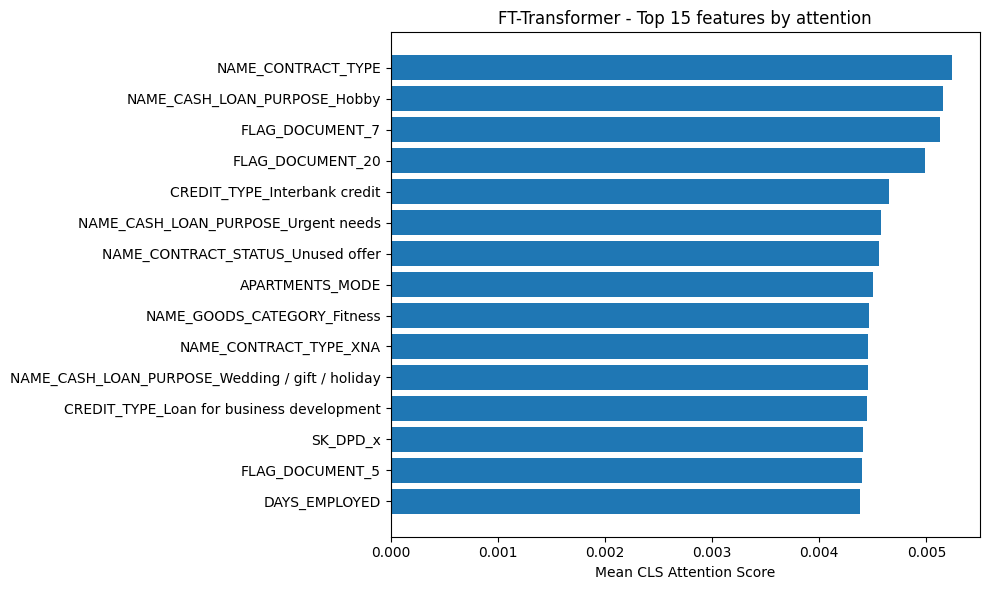

In [42]:
# Compare attention ranking with XGBoost SHAP ranking
shap_path = logger.artifact_path("shap_importance_xgb.csv")

if not os.path.exists(shap_path):
    print(f"XGBoost SHAP CSV not found at {shap_path}")
    print("Run section 8 of 02_home_credit_baselines.ipynb to generate it first.")
else:
    shap_df = pd.read_csv(shap_path)
    shap_top10 = list(shap_df.head(10)["Feature"])
    attn_top10 = list(attn_feature_scores.head(10)["Feature"])

    set_overlap = set(shap_top10) & set(attn_top10)
    print(f"Top-10 overlap: {len(set_overlap)}/10 features")
    print(f"  Both methods agree on: {sorted(set_overlap)}")
    print()

    all_features = list(dict.fromkeys(shap_top10 + attn_top10))
    rows = []
    for f in all_features:
        shap_rank = shap_top10.index(f) + 1 if f in shap_top10 else None
        attn_rank = attn_top10.index(f) + 1 if f in attn_top10 else None
        rows.append({
            "Feature": f,
            "SHAP_rank": shap_rank,
            "Attention_rank": attn_rank,
            "Both_top10": "yes" if (shap_rank and attn_rank) else "",
        })
    comparison_df = pd.DataFrame(rows)
    comparison_df.to_csv(logger.artifact_path("attention_vs_shap_top10.csv"), index=False)
    print(comparison_df.to_string(index=False))

    # Top-15 attention bar chart
    plt.figure(figsize=(10, 6))
    top15 = attn_feature_scores.head(15)
    plt.barh(top15["Feature"][::-1], top15["Attention_Score"][::-1])
    plt.xlabel("Mean CLS Attention Score")
    plt.title("FT-Transformer - Top 15 features by attention")
    plt.tight_layout()
    plt.savefig(logger.artifact_path("attention_top15.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 17. (Optional) Seed variance — flag-gated

Train the tuned config with 5 different seeds, report mean ± std on test
metrics. **Adds ~5x runtime over a single tuned run.** Flag-controlled so
you can run only when budget allows.

Set `RUN_SEED_VARIANCE = True` at the top of Pass 2 to execute.

In [43]:
if not RUN_SEED_VARIANCE:
    print("RUN_SEED_VARIANCE is False — skipping (set True at top of Pass 2 to run)")
else:
    SEEDS = [42, 7, 123, 999, 2024]
    seed_rows = []
    with time_block("seed_variance", logger, model_name="ft_transformer_seed_variance"):
        for seed in SEEDS:
            print(f"\n=== Seed {seed} ===")
            set_torch_seed(seed)
            model_s = build_ft_transformer(
                n_num_features=len(data.num_cols),
                cat_cardinalities=data.cat_cardinalities,
                n_blocks=best_params_ft["n_blocks"],
                d_token=best_params_ft["d_token"],
                attention_n_heads=best_params_ft["attention_n_heads"],
                attention_dropout=best_params_ft["attention_dropout"],
                ffn_d_hidden_multiplier=best_params_ft["ffn_d_hidden_multiplier"],
                ffn_dropout=best_params_ft["ffn_dropout"],
                residual_dropout=best_params_ft["residual_dropout"],
            ).to(DEVICE)

            pw_val = THEORETICAL_POS_WEIGHT if BEST_LOSS_STRATEGY == "weighted_bce" else None
            model_s, _, early_s = train_ft_transformer(
                model_s, train_loader, valid_loader,
                max_epochs=DEV_MAX_EPOCHS if DEV_MODE else 50,
                learning_rate=best_params_ft["learning_rate"],
                weight_decay=best_params_ft["weight_decay"],
                pos_weight=pw_val,
                patience=PATIENCE,
                use_amp=USE_AMP, device=DEVICE, verbose=False,
            )
            wrapper_s = FTTransformerWrapper(
                model_s, data.num_cols, data.cat_cols, device=DEVICE, use_amp=USE_AMP
            )
            test_proba = wrapper_s.predict_proba(X_test)[:, 1]
            test_auc = roc_auc_score(data.y_test, test_proba)
            print(f"  Seed {seed}: test AUC = {test_auc:.5f}")
            seed_rows.append({"seed": seed, "test_auc": test_auc, "valid_auc": float(early_s.best_score)})

    seed_df = pd.DataFrame(seed_rows)
    seed_df.to_csv(logger.artifact_path("seed_variance.csv"), index=False)
    print(f"\nMean test AUC: {seed_df['test_auc'].mean():.5f}")
    print(f"Std test AUC:  {seed_df['test_auc'].std():.5f}")
    print(seed_df)

RUN_SEED_VARIANCE is False — skipping (set True at top of Pass 2 to run)


## 18. Final summary

Reload the cross-run summary CSV (now including FT-Transformer default,
tuned, and MLP baseline rows) plus the timings table.

In [44]:
summary = load_summary(RESULTS_DIR, "home_credit")
summary[[
    "model_name", "AUC", "Gini", "KS_Statistic", "AUCPR",
    "Precision_top10", "Recall_top10",
]]

,model_name,AUC,Gini,KS_Statistic,AUCPR,Precision_top10,Recall_top10
0,lr_default,0.762365,0.524730,0.396683,0.241728,0.272313,0.337362
1,lr_tuned,0.763267,0.526533,0.396435,0.242868,0.274752,0.340383
2,rf_default,0.723839,0.447679,0.340281,0.214968,0.246644,0.318228
3,rf_tuned,0.729130,0.458260,0.339465,0.210351,0.242237,0.300101
4,xgb_default,0.768087,0.536174,0.404768,0.257237,0.281093,0.348238
5,xgb_tuned,0.781593,0.563186,0.423780,0.284842,0.300927,0.372810
6,ft_transformer_default,0.673562,0.347124,0.275616,0.160770,0.183575,0.236025
7,ft_transformer_tuned,0.502916,0.005833,0.046751,0.086613,0.080569,0.105590
8,mlp_baseline,0.728125,0.456250,0.348701,0.188590,0.218905,0.273292


In [45]:
timings = load_timings(ARTIFACTS_DIR)
timings_pivot = (
    timings
    .pivot_table(index="model_name", columns="block", values="seconds", aggfunc="last")
    .round(3)
)
timings_pivot

block,categorical_ablation,imbalance_study,inference_10000,inference_2000,sample_size_study,sensitivity_sweeps,train,tuning_loop
model_name,,,,,,,,
ft_transformer_cat_ablation,43.534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ft_transformer_default,NaN,NaN,2.405,0.435,NaN,NaN,15.038,NaN
ft_transformer_imbalance,NaN,82.415,NaN,NaN,NaN,NaN,NaN,NaN
ft_transformer_sample_size,NaN,NaN,NaN,NaN,38.695,NaN,NaN,NaN
ft_transformer_sweeps,NaN,NaN,NaN,NaN,NaN,294.246,NaN,NaN
ft_transformer_tuned,NaN,NaN,NaN,0.486,NaN,NaN,13.754,0.000
lr_default,NaN,NaN,0.018,NaN,NaN,NaN,18.738,NaN
lr_tuned,NaN,NaN,0.015,NaN,NaN,NaN,111.598,5649.355
mlp_baseline,NaN,NaN,NaN,0.006,NaN,NaN,0.715,NaN


## 19. Decision boundary analysis — axis-aligned vs smooth surfaces

This experiment directly tests the study's central claim: tree ensembles
*"rely on axis-aligned, discrete partitions that may struggle to represent
complex, smooth risk surfaces"*, whereas FT-Transformer learns continuous
representations.

### Method

1. Pick two continuous features that both models rank as important.
2. Build a 2D grid over those features; hold **all other features fixed** at
   their training-set median (numeric) / mode (categorical).
3. Score every grid point with the tuned XGBoost and the tuned FT-Transformer.
4. **Visualize** the two predicted-probability surfaces side by side. XGBoost's
   surface is expected to show axis-aligned rectangular regions with abrupt
   steps; FT-Transformer's is expected to be smooth.
5. **Quantify** the difference with two smoothness metrics computed on each
   surface:
   - *Mean absolute gradient* — average magnitude of change between adjacent
     grid cells. Higher = more jagged.
   - *Gradient concentration (Gini)* — how concentrated the surface's changes
     are into a few sharp edges (tree splits) vs spread smoothly. Higher =
     more "edge-like".

No retraining is needed — this uses the already-tuned models.

> **Interpretation caveat.** A 2D slice with other features held at median is
> illustrative, not exhaustive — the full decision surface is ~43-dimensional.
> The metrics are computed on the slice and reported as such.

In [46]:
# ─── §19 configuration ───────────────────────────────────────────────────
# Two continuous features to sweep. Both should be in num_cols.
#
# For Home Credit we sweep AMT_CREDIT x AMT_INCOME_TOTAL - loan size against
# applicant income, the most intuitive underwriting plane. Note these two are
# positively correlated (larger incomes get larger loans approved), so the
# grid corners are sparse extrapolation regions; the EXT_SOURCE_* features
# (uncorrelated external credit scores) would give a steeper, cleaner risk
# gradient and are listed first in the fallback below.
#
# Robust fallback: if the preferred pair was dropped by the correlation /
# missing-value filters, we fall back through a ranked list of strong
# continuous Home Credit features until two survivors are found.
PREFERRED_BOUNDARY_PAIR = ("AMT_CREDIT", "AMT_INCOME_TOTAL")
BOUNDARY_FALLBACK_FEATURES = [
    "EXT_SOURCE_2", "EXT_SOURCE_3", "EXT_SOURCE_1",
    "AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_GOODS_PRICE",
]

GRID_RESOLUTION = 100   # 100x100 grid = 10,000 points

# Which models to compare. Keys map to display names.
# (XGBoost + FT-Transformer is the core comparison; RF can be added.)
INCLUDE_RF_IN_BOUNDARY = False

# ─── Resolve the feature pair against what survived preprocessing ─────────
fx, fy = PREFERRED_BOUNDARY_PAIR
if fx in data.num_cols and fy in data.num_cols:
    BOUNDARY_FEATURE_X, BOUNDARY_FEATURE_Y = fx, fy
else:
    survivors = [f for f in BOUNDARY_FALLBACK_FEATURES if f in data.num_cols]
    if len(survivors) < 2:
        raise ValueError(
            f"Could not find two boundary features among the fallback list. "
            f"Survivors: {survivors}\nAll numeric features:\n{data.num_cols}"
        )
    BOUNDARY_FEATURE_X, BOUNDARY_FEATURE_Y = survivors[0], survivors[1]
    print(f"Preferred pair {PREFERRED_BOUNDARY_PAIR} not fully available; "
          f"using fallback: {BOUNDARY_FEATURE_X} x {BOUNDARY_FEATURE_Y}")

print(f"Sweeping: x = {BOUNDARY_FEATURE_X},  y = {BOUNDARY_FEATURE_Y}")

# ─── Load the tuned XGBoost model from the baselines notebook's artifacts ──
import xgboost as xgb

xgb_model_path = logger.artifact_path("xgb_model.json")
if not os.path.exists(xgb_model_path):
    raise FileNotFoundError(
        f"Tuned XGBoost not found at {xgb_model_path}. "
        f"Run 02_home_credit_baselines.ipynb section 6 first."
    )
xgb_tuned = xgb.XGBClassifier()
xgb_tuned.load_model(xgb_model_path)
print(f"Loaded tuned XGBoost from {xgb_model_path}")

# FT-Transformer tuned model is already in memory as `model_tuned` (from §12).
# Reload from checkpoint if this cell is run in a fresh session:
if "model_tuned" not in globals():
    ckpt = torch.load(logger.artifact_path("ft_transformer_tuned.pt"), map_location=DEVICE)
    model_tuned = build_ft_transformer(
        n_num_features=len(data.num_cols),
        cat_cardinalities=data.cat_cardinalities,
        n_blocks=ckpt["best_params"]["n_blocks"],
        d_token=ckpt["best_params"]["d_token"],
        attention_n_heads=ckpt["best_params"]["attention_n_heads"],
        attention_dropout=ckpt["best_params"]["attention_dropout"],
        ffn_d_hidden_multiplier=ckpt["best_params"]["ffn_d_hidden_multiplier"],
        ffn_dropout=ckpt["best_params"]["ffn_dropout"],
        residual_dropout=ckpt["best_params"]["residual_dropout"],
    ).to(DEVICE)
    model_tuned.load_state_dict(ckpt["model_state_dict"])
    print("Reloaded tuned FT-Transformer from checkpoint")
else:
    print("Using tuned FT-Transformer already in memory")

Preferred pair ('AMT_CREDIT', 'AMT_INCOME_TOTAL') not fully available; using fallback: EXT_SOURCE_2 x EXT_SOURCE_3
Sweeping: x = EXT_SOURCE_2,  y = EXT_SOURCE_3
Loaded tuned XGBoost from /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/xgb_model.json
Using tuned FT-Transformer already in memory


In [47]:
# Build the 2D grid with all other features held at their training median.
#
# IMPORTANT: features are standard-scaled, so "median" in scaled space is
# approximately 0 for numerics. We use the actual training median to be exact.

x_idx = data.num_cols.index(BOUNDARY_FEATURE_X)
y_idx = data.num_cols.index(BOUNDARY_FEATURE_Y)

# Range for each swept feature: 2nd-98th percentile of TRAIN values (avoids
# outliers stretching the grid)
x_lo, x_hi = np.percentile(data.x_num_train[BOUNDARY_FEATURE_X], [2, 98])
y_lo, y_hi = np.percentile(data.x_num_train[BOUNDARY_FEATURE_Y], [2, 98])

x_grid = np.linspace(x_lo, x_hi, GRID_RESOLUTION)
y_grid = np.linspace(y_lo, y_hi, GRID_RESOLUTION)
xx, yy = np.meshgrid(x_grid, y_grid)
n_points = xx.size

# Background row: every numeric feature at its train median, every
# categorical at its train mode.
num_bg = data.x_num_train.median().values            # [n_num]
cat_bg = data.x_cat_train.mode().iloc[0].values      # [n_cat]

# Tile background across all grid points, then overwrite the 2 swept columns
X_num_grid = np.tile(num_bg, (n_points, 1)).astype(np.float32)   # [n_points, n_num]
X_cat_grid = np.tile(cat_bg, (n_points, 1)).astype(np.int64)     # [n_points, n_cat]

X_num_grid[:, x_idx] = xx.ravel()
X_num_grid[:, y_idx] = yy.ravel()

print(f"Grid: {GRID_RESOLUTION} x {GRID_RESOLUTION} = {n_points:,} points")
print(f"  {BOUNDARY_FEATURE_X}: [{x_lo:.3f}, {x_hi:.3f}] (scaled units)")
print(f"  {BOUNDARY_FEATURE_Y}: [{y_lo:.3f}, {y_hi:.3f}] (scaled units)")
print(f"  Other {len(data.num_cols) - 2} numerics held at median, "
      f"{len(data.cat_cols)} categoricals at mode")

Grid: 100 x 100 = 10,000 points
  EXT_SOURCE_2: [-2.384, 1.335] (scaled units)
  EXT_SOURCE_3: [-2.290, 1.720] (scaled units)
  Other 289 numerics held at median, 14 categoricals at mode


In [ ]:
# Score every grid point with each model.

# XGBoost expects the concatenated (num + cat) DataFrame in the SAME column
# order used during training: num_cols first, then cat_cols.
X_grid_concat = pd.DataFrame(
    np.hstack([X_num_grid, X_cat_grid]),
    columns=list(data.num_cols) + list(data.cat_cols),
)
proba_xgb = xgb_tuned.predict_proba(X_grid_concat)[:, 1].reshape(GRID_RESOLUTION, GRID_RESOLUTION)
print(f"XGBoost grid scored: prob range [{proba_xgb.min():.3f}, {proba_xgb.max():.3f}]")

# FT-Transformer: use the wrapper's split predictor
ft_wrapper_grid = FTTransformerWrapper(
    model=model_tuned, num_cols=data.num_cols, cat_cols=data.cat_cols,
    device=DEVICE, use_amp=USE_AMP,
)
proba_ft = ft_wrapper_grid.predict_proba_split(X_num_grid, X_cat_grid)[:, 1]
proba_ft = proba_ft.reshape(GRID_RESOLUTION, GRID_RESOLUTION)
print(f"FT-Transformer grid scored: prob range [{proba_ft.min():.3f}, {proba_ft.max():.3f}]")

surfaces = {"XGBoost (tuned)": proba_xgb, "FT-Transformer (tuned)": proba_ft}

# Optionally add Random Forest
if INCLUDE_RF_IN_BOUNDARY:
    import joblib
    rf_path = logger.artifact_path("random_forest.pkl")
    if os.path.exists(rf_path):
        rf_tuned = joblib.load(rf_path)
        proba_rf = rf_tuned.predict_proba(X_grid_concat)[:, 1].reshape(GRID_RESOLUTION, GRID_RESOLUTION)
        surfaces["Random Forest (tuned)"] = proba_rf
        print(f"Random Forest grid scored: prob range [{proba_rf.min():.3f}, {proba_rf.max():.3f}]")
    else:
        print(f"RF model not found at {rf_path}; skipping")

In [ ]:
# Side-by-side decision surface heatmaps
n_models = len(surfaces)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5.2), squeeze=False)
axes = axes[0]

# Shared color scale across all panels for fair visual comparison
vmin = min(s.min() for s in surfaces.values())
vmax = max(s.max() for s in surfaces.values())

for ax, (model_name, surface) in zip(axes, surfaces.items()):
    im = ax.contourf(xx, yy, surface, levels=20, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
    ax.contour(xx, yy, surface, levels=10, colors="k", linewidths=0.3, alpha=0.4)
    ax.set_xlabel(f"{BOUNDARY_FEATURE_X} (scaled)")
    ax.set_ylabel(f"{BOUNDARY_FEATURE_Y} (scaled)")
    ax.set_title(f"{model_name}\npredicted P(default)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"Decision surfaces over {BOUNDARY_FEATURE_X} x {BOUNDARY_FEATURE_Y} "
    f"(other features at median)",
    y=1.04, fontsize=12,
)
plt.tight_layout()
plt.savefig(logger.artifact_path("decision_boundary_surfaces.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Saved decision_boundary_surfaces.png")
print("\nVisual reading guide:")
print("  - Axis-aligned rectangular regions + abrupt color steps => tree-style partitioning")
print("  - Smooth gradients / curved contours => continuous representation")

In [ ]:
# Quantify smoothness of each decision surface.
#
# Metric 1 - Mean absolute gradient: average magnitude of change between
#   adjacent grid cells. A piecewise-constant (tree) surface has zero gradient
#   almost everywhere and large spikes at split boundaries; a smooth surface
#   has moderate gradient everywhere. We report the mean.
#
# Metric 2 - Gradient Gini: how concentrated the surface's total variation is.
#   Tree surfaces concentrate all their change into a few sharp edges => high
#   Gini. Smooth surfaces spread change evenly => low Gini.
#
# Metric 3 - Step count: number of grid cells where the local gradient exceeds
#   5x the median gradient (a proxy for counting discrete "jumps").

def surface_smoothness(surface):
    gy, gx = np.gradient(surface)
    grad_mag = np.sqrt(gx**2 + gy**2)
    flat = grad_mag.ravel()

    mean_abs_grad = float(flat.mean())

    # Gini coefficient of the gradient magnitudes
    sorted_g = np.sort(flat)
    n = len(sorted_g)
    cum = np.cumsum(sorted_g)
    if cum[-1] == 0:
        gini = 0.0
    else:
        gini = float((2 * np.sum((np.arange(1, n + 1)) * sorted_g)) / (n * cum[-1]) - (n + 1) / n)

    median_g = np.median(flat)
    step_cells = int((flat > 5 * median_g).sum()) if median_g > 0 else 0

    return {
        "mean_abs_gradient": mean_abs_grad,
        "gradient_gini": gini,
        "step_like_cells": step_cells,
        "total_variation": float(flat.sum()),
    }


smoothness_rows = []
for model_name, surface in surfaces.items():
    m = surface_smoothness(surface)
    m["model"] = model_name
    smoothness_rows.append(m)

smoothness_df = pd.DataFrame(smoothness_rows)[
    ["model", "mean_abs_gradient", "gradient_gini", "step_like_cells", "total_variation"]
]
smoothness_df.to_csv(logger.artifact_path("decision_boundary_smoothness.csv"), index=False)

print("Decision surface smoothness metrics")
print("=" * 70)
print(smoothness_df.to_string(index=False))
print()
print("Reading the metrics:")
print("  - Higher gradient_gini  => change concentrated in sharp edges (tree-like)")
print("  - Higher step_like_cells => more discrete jumps")
print("  - Lower mean_abs_gradient with even spread => smoother surface")

### Interpreting §19 for the write-up

This experiment produces two artifacts for the write-up:

* `decision_boundary_surfaces.png` — the side-by-side visual. Use this as a
  main-text figure. The contrast between XGBoost's rectangular, stepped
  regions and FT-Transformer's smooth gradient is the direct visual evidence
  for the study's "axis-aligned, discrete partitions" claim.
* `decision_boundary_smoothness.csv` — the quantitative backing. The
  `gradient_gini` and `step_like_cells` columns give numbers you can cite:
  XGBoost is expected to score higher on both (its surface change is
  concentrated into a few axis-aligned edges), FT-Transformer lower (change
  spread smoothly).

**Honest framing for the writeup.** This is a 2D slice with the other ~41
features held at their median — it is illustrative of the models' inductive
biases, not a complete characterization of a 43-dimensional surface. State
this explicitly. The claim it supports is about *representational form*
(stepped vs smooth), which is a property of the model class and shows up
clearly even in a 2D slice.

A suggested sentence for the results section:

> "Figure N visualizes each model's predicted default probability over a 2D
> slice of the feature space. XGBoost produces a piecewise-constant surface
> partitioned into axis-aligned rectangular regions, with a gradient-Gini of
> [X] and [Y] step-like transitions. FT-Transformer produces a smooth surface
> (gradient-Gini [X'], [Y'] step-like transitions), consistent with its
> continuous feature representation. This illustrates the representational
> distinction noted in the introduction, though we emphasize it is a 2D slice
> of a higher-dimensional surface.\"

## What's done, what's next

If everything above ran cleanly, the Home Credit FT-Transformer experiments
are **complete**. Artifacts are saved under `artifacts/home_credit/` and
curated summary tables are in `results/`.

### Files produced

* `imbalance_study.csv` — §9
* `cat_ablation.csv` — §10
* `ft_transformer_optuna_study.db` — §11
* `ft_transformer_tuned.pt` + `_history.csv` + `_training_curve.png` — §12
* `sensitivity_sweeps.csv` + `.png` — §13
* `sample_size_study.csv` + `.png` — §14
* MLP rows in summary table — §15
* `attention_importance.csv` — §16
* `seed_variance.csv` — §17 (if enabled)

### Next steps

1. **Copy `notebooks/03_home_credit_ft_transformer.ipynb` to
   `notebooks/04_home_credit_ft_transformer.ipynb`**, swap the data loader,
   re-run. Most of the code is dataset-agnostic.
2. **Curate the study figures** from `artifacts/home_credit/` into
   `results/figures/` — pick the cleanest sensitivity plot, the training
   curve, the sample-size plot.
3. **Compile the study's results** with the cross-model summary
   table (now includes FT-Transformer rows on both datasets).